# **TUẦN 1**

In [1]:
# --- BƯỚC 1: CÀI ĐẶT THƯ VIỆN & CẤU HÌNH MÔI TRƯỜNG ---
!pip install pyspark findspark -q
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, avg, when, to_timestamp, count,
    round as spark_round, datediff, lit, expr
)
import os

In [2]:
# --- BƯỚC 2: KHỞI TẠO SPARK SESSION ---
# Cấu hình memory phù hợp với môi trường Colab
spark = SparkSession.builder \
    .appName("Olist_Week1_Preprocessing_Fixed") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

print("✅ Spark Session đã khởi tạo!")

✅ Spark Session đã khởi tạo!


In [3]:
# --- BƯỚC 3: MOUNT GOOGLE DRIVE & LOAD DỮ LIỆU ---
import os
import shutil
from google.colab import drive

# Kiểm tra và dọn dẹp mount point nếu nó không phải là mount point thật sự nhưng lại có file
mount_path = '/content/drive'
if os.path.exists(mount_path) and os.listdir(mount_path):
    print(f"⚠️ Thư mục {mount_path} không trống. Đang dọn dẹp...")
    try:
        # Chỉ xóa nếu không phải là drive đã mount thành công
        if not os.path.ismount(mount_path):
            shutil.rmtree(mount_path)
            os.makedirs(mount_path)
    except Exception as e:
        print(f"❌ Không thể dọn dẹp: {e}")

# Thực hiện mount
try:
    drive.mount(mount_path, force_remount=True)
    print("✅ Mount Google Drive thành công!")
except Exception as e:
    print(f"❌ Lỗi khi mount: {e}")

⚠️ Thư mục /content/drive không trống. Đang dọn dẹp...
Mounted at /content/drive
✅ Mount Google Drive thành công!


In [4]:
data_folder = "/content"

In [5]:
import os
FILES = {
    "orders": "olist_orders_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "translation": "product_category_name_translation.csv"
}

In [6]:
# --- [4] LOAD DỮ LIỆU ---
print("\n📥 Loading dữ liệu...")
dfs = {}
for key, filename in FILES.items():
    filepath = os.path.join(data_folder, filename)
    if os.path.exists(filepath):
        dfs[key] = spark.read.csv(filepath, header=True, inferSchema=True, escape='"')
        print(f"  ✅ Loaded {key}: {dfs[key].count()} rows")
    else:
        print(f"  ❌ Missing {filename}")


📥 Loading dữ liệu...
  ✅ Loaded orders: 99441 rows
  ✅ Loaded customers: 99441 rows
  ✅ Loaded items: 112650 rows
  ✅ Loaded payments: 103886 rows
  ✅ Loaded reviews: 104162 rows
  ✅ Loaded products: 32951 rows
  ✅ Loaded sellers: 3095 rows
  ✅ Loaded geolocation: 751259 rows
  ✅ Loaded translation: 71 rows


In [7]:

# --- [5] XỬ LÝ GEOLOCATION ---
print("\n🔧 Xử lý geolocation...")
df_geo_clean = dfs["geolocation"].groupBy("geolocation_zip_code_prefix") \
    .agg(
        spark_round(avg("geolocation_lat"), 4).alias("lat_avg"),
        spark_round(avg("geolocation_lng"), 4).alias("lng_avg")
    )


🔧 Xử lý geolocation...


In [8]:
print("\n🔗 Join các bảng...")
df_master = dfs["orders"].alias("o") \
    .join(dfs["customers"].alias("c"), col("o.customer_id") == col("c.customer_id"), "left") \
    .join(df_geo_clean.alias("g"), col("c.customer_zip_code_prefix") == col("g.geolocation_zip_code_prefix"), "left") \
    .join(dfs["items"].alias("oi"), col("o.order_id") == col("oi.order_id"), "left") \
    .join(dfs["products"].alias("p"), col("oi.product_id") == col("p.product_id"), "left") \
    .join(dfs["translation"].alias("t"), col("p.product_category_name") == col("t.product_category_name"), "left") \
    .join(dfs["sellers"].alias("s"), col("oi.seller_id") == col("s.seller_id"), "left") \
    .join(dfs["payments"].alias("op"), col("o.order_id") == col("op.order_id"), "left") \
    .join(dfs["reviews"].alias("r"), col("o.order_id") == col("r.order_id"), "left")

print(f"  ✅ Tổng bản ghi sau join: {df_master.count()}")


🔗 Join các bảng...
  ✅ Tổng bản ghi sau join: 119143


In [9]:
# --- [7] XỬ LÝ NULL ---
print("\n🧹 Xử lý null...")
df_master = df_master.withColumn(
    "review_comment_message",
    when(col("review_comment_message").isNull(), "No Comment")
    .otherwise(col("review_comment_message"))
).fillna({"review_score": 0})


🧹 Xử lý null...


In [10]:
# --- [8] CONVERT TIMESTAMP ---
print("\n🕐 Convert timestamp...")
timestamp_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date", "review_creation_date",
    "review_answer_timestamp"
]
for t_col in timestamp_cols:
    if t_col in df_master.columns:
        df_master = df_master.withColumn(t_col, to_timestamp(col(t_col)))



🕐 Convert timestamp...


In [11]:
# 5.3. Schema của orders
print(f"\n  Schema - Orders dataset:")
dfs["orders"].printSchema()


  Schema - Orders dataset:
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)



In [12]:
# --- [6] TIỀN XỬ LÝ DỮ LIỆU ---
print("\n🔧 Bắt đầu tiền xử lý...")

# 6.1. Xử lý geolocation: lấy tọa độ trung bình theo zip_code
df_geo_clean = dfs["geolocation"].groupBy("geolocation_zip_code_prefix") \
    .agg(
        spark_round(avg("geolocation_lat"), 4).alias("lat_avg"),
        spark_round(avg("geolocation_lng"), 4).alias("lng_avg")
    )
print("  ✅ Đã xử lý trùng lặp geolocation")

# 6.2. Join các bảng theo thứ tự hợp lý, xử lý cột trùng lặp
# Select columns explicitly to avoid duplicates after join
# Initial orders DataFrame
df_master = dfs["orders"].alias("o") \
    .select(
        col("o.order_id"),
        col("o.customer_id"),
        col("o.order_status"),
        col("o.order_purchase_timestamp"),
        col("o.order_approved_at"),
        col("o.order_delivered_carrier_date"),
        col("o.order_delivered_customer_date"),
        col("o.order_estimated_delivery_date")
    )

# Join with customers
df_master = df_master.join(
    dfs["customers"].alias("c").select(
        col("c.customer_id").alias("customer_id_c"), # Rename to avoid duplicate
        col("c.customer_unique_id"),
        col("c.customer_zip_code_prefix"),
        col("c.customer_city"),
        col("c.customer_state")
    ),
    df_master["customer_id"] == col("customer_id_c"),
    "left"
).drop("customer_id_c") # Drop the renamed customer_id from customers table

# Join with df_geo_clean
df_master = df_master.join(
    df_geo_clean.alias("g").select(
        col("g.geolocation_zip_code_prefix").alias("geo_zip_prefix"), # Rename to avoid duplicate
        col("g.lat_avg"),
        col("g.lng_avg")
    ),
    df_master["customer_zip_code_prefix"] == col("geo_zip_prefix"),
    "left"
).drop("geo_zip_prefix") # Drop the renamed geolocation_zip_code_prefix from geo_clean table

# Join with items
df_master = df_master.join(
    dfs["items"].alias("oi").select(
        col("oi.order_id").alias("order_id_oi"), # Rename to avoid duplicate
        col("oi.order_item_id"),
        col("oi.product_id"),
        col("oi.seller_id"),
        col("oi.shipping_limit_date"),
        col("oi.price"),
        col("oi.freight_value")
    ),
    df_master["order_id"] == col("order_id_oi"),
    "left"
).drop("order_id_oi") # Drop the renamed order_id from items table

# Join with products
df_master = df_master.join(
    dfs["products"].alias("p").select(
        col("p.product_id").alias("product_id_p"), # Rename to avoid duplicate
        col("p.product_category_name"),
        col("p.product_name_lenght"),
        col("p.product_description_lenght"),
        col("p.product_photos_qty"),
        col("p.product_weight_g"),
        col("p.product_length_cm"),
        col("p.product_height_cm"),
        col("p.product_width_cm")
    ),
    df_master["product_id"] == col("product_id_p"),
    "left"
).drop("product_id_p") # Drop the renamed product_id from products table

# Join with translation
df_master = df_master.join(
    dfs["translation"].alias("t").select(
        col("t.product_category_name").alias("product_category_name_t"), # Rename to avoid duplicate
        col("t.product_category_name_english")
    ),
    df_master["product_category_name"] == col("product_category_name_t"),
    "left"
).drop("product_category_name_t") # Drop the renamed product_category_name from translation table

# Join with sellers
df_master = df_master.join(
    dfs["sellers"].alias("s").select(
        col("s.seller_id").alias("seller_id_s"), # Rename to avoid duplicate
        col("s.seller_zip_code_prefix"),
        col("s.seller_city"),
        col("s.seller_state")
    ),
    df_master["seller_id"] == col("seller_id_s"),
    "left"
).drop("seller_id_s") # Drop the renamed seller_id from sellers table

# Join with payments
df_master = df_master.join(
    dfs["payments"].alias("op").select(
        col("op.order_id").alias("order_id_op"), # Rename to avoid duplicate
        col("op.payment_sequential"),
        col("op.payment_type"),
        col("op.payment_installments"),
        col("op.payment_value")
    ),
    df_master["order_id"] == col("order_id_op"),
    "left"
).drop("order_id_op") # Drop the renamed order_id from payments table

# Join with reviews
df_master = df_master.join(
    dfs["reviews"].alias("r").select(
        col("r.order_id").alias("order_id_r"), # Rename to avoid duplicate
        col("r.review_id"),
        col("r.review_score"),
        col("r.review_comment_title"),
        col("r.review_comment_message"),
        col("r.review_creation_date"),
        col("r.review_answer_timestamp")
    ),
    df_master["order_id"] == col("order_id_r"),
    "left"
).drop("order_id_r") # Drop the renamed order_id from reviews table

print(f"  ✅ Đã join 9 bảng. Tổng bản ghi: {df_master.count()}")

# 6.3. Xử lý null cho review_comment_message
df_master = df_master.withColumn(
    "review_comment_message",
    when(col("review_comment_message").isNull(), "No Comment")
    .otherwise(col("review_comment_message"))
)
print("  ✅ Đã fill null review_comment_message")

# 6.4. Fill null cho review_score (nếu có)
df_master = df_master.fillna({"review_score": 0})

# 6.5. Convert timestamp columns
timestamp_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date", "review_creation_date",
    "review_answer_timestamp",
    "shipping_limit_date" # Added this one as it's a timestamp
]
for t_col in timestamp_cols:
    if t_col in df_master.columns:
        df_master = df_master.withColumn(t_col, to_timestamp(col(t_col)))
print("  ✅ Đã convert các cột thời gian sang TimestampType")

# 6.6. Tạo feature mới: delivery_delay_days (nếu có đủ dữ liệu)
if "order_delivered_customer_date" in df_master.columns and "order_estimated_delivery_date" in df_master.columns:
    df_master = df_master.withColumn(
        "delivery_delay_days",
        datediff(col("order_delivered_customer_date"), col("order_estimated_delivery_date"))
    )
    print("  ✅ Đã tạo feature: delivery_delay_days")


🔧 Bắt đầu tiền xử lý...
  ✅ Đã xử lý trùng lặp geolocation
  ✅ Đã join 9 bảng. Tổng bản ghi: 119143
  ✅ Đã fill null review_comment_message
  ✅ Đã convert các cột thời gian sang TimestampType
  ✅ Đã tạo feature: delivery_delay_days


In [13]:
# --- [7] KIỂM TRA KẾT QUẢ CUỐI ---
print("\n📋 Kết quả sau tiền xử lý:")
print(f"  • Tổng columns: {len(df_master.columns)}")
print(f"  • Tổng rows: {df_master.count()}")
print(f"\n  • Sample schema (10 columns đầu):")
for field in df_master.schema.fields[:10]:
    print(f"      {field.name}: {field.dataType}")

# Hiển thị sample data
print(f"\n  • Sample data (3 rows):")
df_master.limit(3).toPandas().T  # Hiển thị dạng transpose cho dễ đọc


📋 Kết quả sau tiền xử lý:
  • Tổng columns: 43
  • Tổng rows: 119143

  • Sample schema (10 columns đầu):
      order_id: StringType()
      customer_id: StringType()
      order_status: StringType()
      order_purchase_timestamp: TimestampType()
      order_approved_at: TimestampType()
      order_delivered_carrier_date: TimestampType()
      order_delivered_customer_date: TimestampType()
      order_estimated_delivery_date: TimestampType()
      customer_unique_id: StringType()
      customer_zip_code_prefix: IntegerType()

  • Sample data (3 rows):


,0,1,2
order_id,53cdb2fc8bc7dce0b6741e2150273451,e481f51cbdc54678b7cc49136f2d6af7,e481f51cbdc54678b7cc49136f2d6af7
customer_id,b0830fb4747a6c6d20dea0b8c802d7ef,9ef432eb6251297304e76186b10a928d,9ef432eb6251297304e76186b10a928d
order_status,delivered,delivered,delivered
order_purchase_timestamp,2018-07-24 20:41:37,2017-10-02 10:56:33,2017-10-02 10:56:33
order_approved_at,2018-07-26 03:24:27,2017-10-02 11:07:15,2017-10-02 11:07:15
order_delivered_carrier_date,2018-07-26 14:31:00,2017-10-04 19:55:00,2017-10-04 19:55:00
order_delivered_customer_date,2018-08-07 15:27:45,2017-10-10 21:25:13,2017-10-10 21:25:13
order_estimated_delivery_date,2018-08-13 00:00:00,2017-10-18 00:00:00,2017-10-18 00:00:00
customer_unique_id,af07308b275d755c9edb36a90c618231,7c396fd4830fd04220f754e42b4e5bff,7c396fd4830fd04220f754e42b4e5bff
customer_zip_code_prefix,47813,3149,3149


In [14]:
# --- [8] LƯU DỮ LIỆU ĐÃ XỬ LÝ ---
# ⚠️ QUAN TRỌNG: Lưu vào Google Drive để không mất dữ liệu khi Colab reset
print("\n💾 Đang chuẩn bị lưu dữ liệu...")

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Tạo folder lưu trữ
SAVE_PATH = "/content/drive/MyDrive/Olist_Project/processed_data/week1"
os.makedirs(SAVE_PATH, exist_ok=True)

# Lưu dưới dạng Parquet (nhanh hơn CSV, giữ nguyên schema)
df_master.write.mode("overwrite").parquet(SAVE_PATH + "/master_dataset.parquet")
print(f"  ✅ Đã lưu dataset vào: {SAVE_PATH}")

# Lưu thêm file schema để tham khảo
with open(SAVE_PATH + "/schema_info.txt", "w") as f:
    f.write(df_master._jdf.schema().treeString())
print(f"  ✅ Đã lưu schema vào: {SAVE_PATH}/schema_info.txt")


💾 Đang chuẩn bị lưu dữ liệu...
Mounted at /content/drive
  ✅ Đã lưu dataset vào: /content/drive/MyDrive/Olist_Project/processed_data/week1
  ✅ Đã lưu schema vào: /content/drive/MyDrive/Olist_Project/processed_data/week1/schema_info.txt


In [15]:
# --- [9] DỌN DẸP ---
spark.stop()
print("\n🎉 HOÀN THÀNH TUẦN 1! Dữ liệu đã sẵn sàng cho Week 2.")


🎉 HOÀN THÀNH TUẦN 1! Dữ liệu đã sẵn sàng cho Week 2.


# **TUẦN 2**

In [16]:
# =============================================================================
# WEEK 2: ML PIPELINE & MODELING - OLIST E-COMMERCE
# =============================================================================

# [1] CÀI ĐẶT THƯ VIỆN
!pip install pyspark findspark -q
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, avg, when, to_timestamp, count, datediff, max as spark_max,
    sum as spark_sum, round as spark_round, lit, expr
)
from pyspark.sql.types import IntegerType # Import IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler,
    ChiSqSelector, Tokenizer, StopWordsRemover, CountVectorizer, IDF
)
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier, NaiveBayes,
    LinearSVC, GBTClassifier
)
from pyspark.ml.regression import (
    LinearRegression, DecisionTreeRegressor, RandomForestRegressor
)
from pyspark.ml.clustering import KMeans, BisectingKMeans, GaussianMixture
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator, RegressionEvaluator,
    ClusteringEvaluator
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.recommendation import ALS
from pyspark.ml.fpm import FPGrowth

import os
import time

# [2] KHỞI TẠO SPARK SESSION
spark = SparkSession.builder \
    .appName("Olist_Week2_ML_Pipeline") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

print("✅ Spark Session đã khởi tạo!")
print(f"Spark Version: {spark.version}")

# [3] MOUNT GOOGLE DRIVE & LOAD DỮ LIỆU TUẦN 1
from google.colab import drive
drive.mount('/content/drive')

# Đường dẫn dataset đã xử lý từ Tuần 1
DATA_PATH = "/content/drive/MyDrive/Olist_Project/processed_data/week1/master_dataset.parquet"
df_master = spark.read.parquet(DATA_PATH)

# Chuyển đổi review_score sang kiểu số nguyên
df_master = df_master.withColumn("review_score", col("review_score").cast(IntegerType()))

print(f"\n✅ Loaded dataset: {df_master.count()} rows, {len(df_master.columns)} columns")
df_master.printSchema()

✅ Spark Session đã khởi tạo!
Spark Version: 4.0.2
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Loaded dataset: 119143 rows, 43 columns
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- lat_avg: double (nullable = true)
 |-- lng_avg: double (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: strin

In [17]:
# =============================================================================
# [4] XÂY DỰNG SPARK ML PIPELINE
# =============================================================================

from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.sql.functions import col, isnan
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.ml.linalg import VectorUDT
from pyspark.sql.types import BooleanType
from pyspark.sql.functions import udf
import numpy as np
import time, os

# [1] KHỞI TẠO SPARK SESSION TỐI ƯU
spark = SparkSession.builder \
    .appName("Olist_Week2_Optimized") \
    .config("spark.sql.shuffle.partitions", "50") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# [2] LOAD DỮ LIỆU TỪ TUẦN 1
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Olist_Project/processed_data/week1/master_dataset.parquet"
df_master = spark.read.parquet(DATA_PATH)
print(f"✅ Loaded {df_master.count()} rows")

# [3] CHỌN COLUMNS QUAN TRỌNG (GIẢM FEATURES)
categorical_cols = ["order_status", "customer_state", "payment_type"]
numeric_cols     = ["price", "freight_value", "payment_value", "delivery_delay_days"]

# ✅ FIX THÊM: ép kiểu + fillna + lọc NaN/Inf từng cột trước khi vào Pipeline
for c in ["price", "freight_value", "payment_value"]:
    df_master = df_master.withColumn(c, col(c).cast(DoubleType()))
df_master = df_master.withColumn(
    "delivery_delay_days",
    col("delivery_delay_days").cast(IntegerType()).cast(DoubleType())
)
df_master = df_master.withColumn("review_score", col("review_score").cast(IntegerType()))

df_master = df_master.fillna({
    "price": 0.0, "freight_value": 0.0,
    "payment_value": 0.0, "delivery_delay_days": 0.0,
    "review_score": 0,
    "order_status": "unknown",
    "customer_state": "unknown",
    "payment_type": "unknown"
})

for c in numeric_cols:
    df_master = df_master.filter(col(c).isNotNull() & ~isnan(col(c)))

print(f"✅ Sau khi làm sạch: {df_master.count()} rows")

# [4] XÂY DỰNG PIPELINE ĐƠN GIẢN HÓA
print("\n🔧 Building Optimized Pipeline...")

# StringIndexer
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx",
                          handleInvalid="keep") for c in categorical_cols]

# OneHotEncoder
encoder = OneHotEncoder(
    inputCols=[c+"_idx" for c in categorical_cols],
    outputCols=[c+"_oh" for c in categorical_cols]
)

# VectorAssembler — ✅ FIX: đổi handleInvalid="keep" → "skip"
assembler = VectorAssembler(
    inputCols=numeric_cols + [c+"_oh" for c in categorical_cols],
    outputCol="features",
    handleInvalid="skip"
)

# Pipeline (NO ChiSqSelector, NO StandardScaler)
pipeline = Pipeline(stages=indexers + [encoder, assembler])

# Fit & Transform
start_time = time.time()
pipeline_model = pipeline.fit(df_master)
df_transformed = pipeline_model.transform(df_master)
pipeline_time  = time.time() - start_time

print(f"✅ Pipeline completed in {pipeline_time:.2f} seconds")
print(f"✅ Features count: {len(df_transformed.columns)}")

# ✅ FIX THÊM: UDF quét vector loại bỏ hàng vẫn còn NaN/Inf ẩn bên trong
def has_nan_inf(v):
    if v is None:
        return True
    arr = v.toArray()
    return bool(np.any(np.isnan(arr)) or np.any(np.isinf(arr)))

has_nan_inf_udf  = udf(has_nan_inf, BooleanType())
df_transformed   = df_transformed.filter(~has_nan_inf_udf(col("features")))
df_transformed   = df_transformed.dropna(subset=["payment_value", "review_score"])

# Cache for faster modeling
df_transformed.cache()
print(f"✅ DataFrame cached: {df_transformed.count()} rows sạch")

# Save pipeline
SAVE_PATH = "/content/drive/MyDrive/Olist_Project/models/week2"
os.makedirs(SAVE_PATH, exist_ok=True)
pipeline_model.write().overwrite().save(SAVE_PATH + "/pipeline_model")
print(f"✅ Pipeline saved to {SAVE_PATH}")

# [5] TRAIN/TEST SPLIT
train_data, test_data = df_transformed.randomSplit([0.8, 0.2], seed=42)
print(f"✅ Train: {train_data.count()} rows, Test: {test_data.count()} rows")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded 119143 rows
✅ Sau khi làm sạch: 119143 rows

🔧 Building Optimized Pipeline...
✅ Pipeline completed in 9.90 seconds
✅ Features count: 50
✅ DataFrame cached: 119143 rows sạch
✅ Pipeline saved to /content/drive/MyDrive/Olist_Project/models/week2
✅ Train: 95297 rows, Test: 23846 rows


In [18]:
# =============================================================================
# [5] FEATURE ENGINEERING - RFM ANALYSIS
# =============================================================================
print("\n" + "="*60)
print("📊 FEATURE ENGINEERING - RFM ANALYSIS")
print("="*60)

# [5.1] Tính toán RFM
print("\n📌 Tính toán RFM metrics...")

# Reference date
reference_date = df_master.agg(spark_max("order_purchase_timestamp")).collect()[0][0]
print(f"  Reference Date: {reference_date}")

# RFM Calculation
# Sử dụng lit(reference_date) để chuyển đổi biến Python sang Spark Column
rfm_df = df_master.groupBy("customer_unique_id").agg(
    datediff(lit(reference_date), spark_max("order_purchase_timestamp")).alias("recency"),
    count("order_id").alias("frequency"),
    spark_sum("payment_value").alias("monetary")
)

print(f"  ✅ RFM features: {rfm_df.count()} customers")

# [5.2] Thống kê mô tả RFM
print("\n📌 Thống kê mô tả RFM:")
rfm_df.describe().show()

# [5.3] Lưu RFM dataset
rfm_df.write.mode("overwrite").parquet(SAVE_PATH + "/rfm_dataset.parquet")
print(f"  ✅ RFM dataset đã lưu")


📊 FEATURE ENGINEERING - RFM ANALYSIS

📌 Tính toán RFM metrics...
  Reference Date: 2018-10-17 17:30:18
  ✅ RFM features: 96096 customers

📌 Thống kê mô tả RFM:
+-------+--------------------+------------------+------------------+------------------+
|summary|  customer_unique_id|           recency|         frequency|          monetary|
+-------+--------------------+------------------+------------------+------------------+
|  count|               96096|             96096|             96096|             96096|
|   mean|                NULL|288.10879745254744|1.2398330835830835|214.15734276140086|
| stddev|                NULL|153.41786878790512|0.8531584601718882| 644.8919867657858|
|    min|0000366f3b9a7992b...|                 0|                 1|               0.0|
|    max|ffffd2657e2aad290...|               773|                75|         109312.64|
+-------+--------------------+------------------+------------------+------------------+

  ✅ RFM dataset đã lưu


In [19]:
# =============================================================================
# [6] TEXT FEATURE EXTRACTION - TF-IDF
# =============================================================================
print("\n" + "="*60)
print("📝 TEXT FEATURE EXTRACTION - TF-IDF")
print("="*60)

# [6.1] Text Pipeline
print("\n📌 Xây dựng Text Pipeline...")

# Tokenizer
tokenizer = Tokenizer(inputCol="review_comment_message", outputCol="tokens")

# StopWordsRemover
remover = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")

# CountVectorizer
cv = CountVectorizer(
    inputCol="filtered_tokens",
    outputCol="raw_features",
    vocabSize=1000,
    minDF=5
)

# IDF
idf = IDF(inputCol="raw_features", outputCol="tfidf_features")

# Text Pipeline
text_pipeline = Pipeline(stages=[tokenizer, remover, cv, idf])

# Fit Text Pipeline
start_time = time.time()
text_model = text_pipeline.fit(df_master)
df_with_tfidf = text_model.transform(df_master)
text_time = time.time() - start_time

print(f"  ✅ Text Pipeline hoàn thành trong {text_time:.2f} giây")
print(f"  ✅ TF-IDF features: {len(df_with_tfidf.columns)} columns")

# Lưu text model
text_model.write().overwrite().save(SAVE_PATH + "/text_model")
print(f"  ✅ Text model đã lưu")


📝 TEXT FEATURE EXTRACTION - TF-IDF

📌 Xây dựng Text Pipeline...
  ✅ Text Pipeline hoàn thành trong 30.40 giây
  ✅ TF-IDF features: 47 columns
  ✅ Text model đã lưu


In [20]:
# =============================================================================
# [7] CLASSIFICATION MODELS – 5 Models
# =============================================================================
import time, os
import pandas as pd
from pyspark.sql.functions import when, col
from pyspark.sql.types import DoubleType
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier,
    NaiveBayes, LinearSVC, GBTClassifier
)
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator, BinaryClassificationEvaluator
)
from pyspark.ml.feature import MinMaxScaler
SAVE_PATH   = "/content/drive/MyDrive/OlistProject/models/week2"
FIGURE_PATH = "/content/drive/MyDrive/OlistProject/figures"
os.makedirs(SAVE_PATH, exist_ok=True)
os.makedirs(FIGURE_PATH, exist_ok=True)

print("\n" + "="*60)
print("🎯 CLASSIFICATION MODELS (Target: review_score binary)")
print("="*60)

# Label binary 0/1
df_cls = df_transformed.withColumn(
    "label",
    when(col("review_score") >= 4, 1.0).otherwise(0.0).cast(DoubleType())
)

# ✅ Chuẩn bị 2 bộ features
mms_model  = MinMaxScaler(inputCol="features", outputCol="features_mms").fit(df_cls)
df_cls     = mms_model.transform(df_cls).cache()

train_cls, test_cls = df_cls.randomSplit([0.8, 0.2], seed=42)
print(f"  Train: {train_cls.count()} | Test: {test_cls.count()}")
print("  Label distribution:")
test_cls.groupBy("label").count().show()

models_cls = {
    "LogisticRegression": LogisticRegression(
        featuresCol="features", labelCol="label", maxIter=100, regParam=0.01
    ),
    "RandomForest": RandomForestClassifier(
        featuresCol="features", labelCol="label", numTrees=50, maxDepth=8, seed=42
    ),
    "NaiveBayes": NaiveBayes(
        featuresCol="features_mms", labelCol="label",
        smoothing=1.0, modelType="multinomial"
    ),
    "LinearSVC": LinearSVC(
        featuresCol="features", labelCol="label", maxIter=100, regParam=0.01
    ),
    "GBTClassifier": GBTClassifier(
        featuresCol="features", labelCol="label",
        maxIter=50, maxDepth=5, stepSize=0.1, seed=42
    ),
}

acc_eval  = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
f1_eval   = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")
prec_eval = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedPrecision")
rec_eval  = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedRecall")
auc_eval  = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")

cls_results = {}

# ── In header bảng đầy đủ 6 cột ──────────────────────────────────────────────
print(f"\n{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>8} {'AUC':>8} {'Time(s)':>9}")
print("-"*85)

for name, clf in models_cls.items():
    try:
        t0      = time.time()
        trained = clf.fit(train_cls)
        preds   = trained.transform(test_cls)
        elapsed = time.time() - t0

        acc  = acc_eval.evaluate(preds)
        prec = prec_eval.evaluate(preds)
        rec  = rec_eval.evaluate(preds)
        f1   = f1_eval.evaluate(preds)

        try:
            auc     = auc_eval.evaluate(preds)
            auc_str = f"{auc:>8.4f}"
        except Exception:
            auc     = float("nan")
            auc_str = f"{'N/A':>8}"

        cls_results[name] = {
            "preds": preds, "acc": acc, "prec": prec,
            "rec": rec, "f1": f1, "auc": auc,
            "time": elapsed, "model": trained
        }
        print(f"{name:<22} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>8.4f} {auc_str} {elapsed:>9.1f}")

    except Exception as e:
        print(f"{name:<22} ❌ {str(e)[:80]}")

print("-"*85)

# Best model + lưu
if cls_results:
    best_cls = max(cls_results, key=lambda k: cls_results[k]["acc"])
    b = cls_results[best_cls]
    print(f"\n🏆 Best: {best_cls}")
    print(f"   Accuracy={b['acc']:.4f} | Precision={b['prec']:.4f} | Recall={b['rec']:.4f} | F1={b['f1']:.4f}")
    b["model"].write().overwrite().save(SAVE_PATH + "/best_cls_model")
    print("✅ Best model đã lưu")

# ── Lưu CSV ───────────────────────────────────────────────────────────────────
import pandas as pd, os
os.makedirs(FIGURE_PATH, exist_ok=True)
df_tbl = pd.DataFrame([
    {"Model": k, "Accuracy": v["acc"], "Precision": v["prec"],
     "Recall": v["rec"], "F1": v["f1"], "AUC": v["auc"], "Time(s)": v["time"]}
    for k, v in cls_results.items()
])
CSV_PATH = f"{FIGURE_PATH}/classification_results_full.csv"
df_tbl.to_csv(CSV_PATH, index=False)
print(f"\n✅ Đã lưu CSV: {CSV_PATH}")
print("✅ Best model đã lưu")


🎯 CLASSIFICATION MODELS (Target: review_score binary)
  Train: 95297 | Test: 23846
  Label distribution:
+-----+-----+
|label|count|
+-----+-----+
|  0.0| 6034|
|  1.0|17812|
+-----+-----+


Model                    Accuracy  Precision     Recall       F1      AUC   Time(s)
-------------------------------------------------------------------------------------
LogisticRegression         0.7864     0.7996     0.7864   0.7310   0.6735       8.7
RandomForest               0.8009     0.8052     0.8009   0.7607   0.6987      23.7
NaiveBayes                 0.7682     0.7902     0.7682   0.6913   0.5893       2.4
LinearSVC                  0.7682     0.7902     0.7682   0.6913   0.6947      40.0
GBTClassifier              0.8066     0.8084     0.8066   0.7715   0.7264      59.3
-------------------------------------------------------------------------------------

🏆 Best: GBTClassifier
   Accuracy=0.8066 | Precision=0.8084 | Recall=0.8066 | F1=0.7715
✅ Best model đã lưu

✅ Đã lưu CSV: /content

In [37]:
import pyspark
# =============================================================================
# [7A] HYPERPARAMETER TUNING - CROSSVALIDATOR
# =============================================================================
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator,
    RegressionEvaluator
)
from pyspark.ml.classification import GBTClassifier, LogisticRegression
from pyspark.ml.regression import RandomForestRegressor
from pyspark.sql.functions import col, when, isnan
from pyspark.sql.types import DoubleType
import time

print("=" * 60)
print("HYPERPARAMETER TUNING VOI CROSSVALIDATOR")
print("=" * 60)

# ✅ FIX 1: Đảm bảo Spark Session active và ổn định
from pyspark.sql import SparkSession
spark = SparkSession.getActiveSession()
if spark is None:
    spark = SparkSession.builder \
        .appName("HyperparameterTuning") \
        .config("spark.sql.shuffle.partitions", "200") \
        .config("spark.driver.memory", "4g") \
        .getOrCreate()
print("✅ Spark session active")

# Initialize reg_results if not already defined
if 'reg_results' not in globals():
    reg_results = {}

# =============================================================
# FIX 2: Kiểm tra train_reg / test_reg - KHÔNG TỰ TẠO LẠI
# =============================================================
print("\n[0] Kiem tra train_reg / test_reg...")

# ✅ FIX QUAN TRỌNG: KHÔNG dùng try-except để tự tạo lại DataFrames phức tạp
# Thay vào đó: Yêu cầu user chạy cell Regression Models trước

if 'train_reg' not in globals() or 'test_reg' not in globals():
    print("  ❌ train_reg/test_reg chua ton tai!")
    print("  💡 Vui lòng chạy cell [8] REGRESSION MODELS trước để tạo train_reg/test_reg")
    print("  ⚠️ Bo qua phan tuning Regression de tiep tuc voi Classification...")
    # Continue với classification tuning thôi
    skip_regression_tuning = True
else:
    try:
        # Materialize để kiểm tra DataFrame có hợp lệ không
        train_reg_count = train_reg.count()
        test_reg_count = test_reg.count()
        print(f"  ✅ train_reg: {train_reg_count} rows")
        print(f"  ✅ test_reg: {test_reg_count} rows")
        skip_regression_tuning = False
    except Exception as e:
        print(f"  ❌ Loi kiem tra train_reg: {e}")
        print("  💡 Chay lai cell [8] REGRESSION MODELS de tao lai data")
        skip_regression_tuning = True

# Kiểm tra train_cls tương tự
if 'train_cls' not in globals() or 'test_cls' not in globals():
    print("  ❌ train_cls/test_cls chua ton tai!")
    print("  💡 Vui lòng chạy cell [7] CLASSIFICATION MODELS trước")
    raise Exception("Chay cell Classification Models truoc khi tuning")
else:
    try:
        train_cls_count = train_cls.count()
        test_cls_count = test_cls.count()
        print(f"  ✅ train_cls: {train_cls_count} rows")
        print(f"  ✅ test_cls: {test_cls_count} rows")
    except Exception as e:
        print(f"  ❌ Loi kiem tra train_cls: {e}")
        raise Exception("Chay lai cell Classification Models")

# =============================================================
# 7.1. Tuning GBTClassifier
# =============================================================
print("\n[1/3] Tuning GBTClassifier...")

gbt_tune = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    seed=42
)

paramGrid_clf = (ParamGridBuilder()
    .addGrid(gbt_tune.maxIter,  [30, 50])
    .addGrid(gbt_tune.maxDepth, [5, 7])
    .addGrid(gbt_tune.stepSize, [0.05, 0.1])
    .build())

print("  Tong configs: " + str(len(paramGrid_clf)) + " | Folds: 3")

clf_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", metricName="accuracy")

cv_clf = CrossValidator(
    estimator=gbt_tune,
    estimatorParamMaps=paramGrid_clf,
    evaluator=clf_evaluator,
    numFolds=3,
    seed=42,
    parallelism=2
)

print("  Dang chay CV GBT...")
t0 = time.time()
cvModel_clf = cv_clf.fit(train_cls)
elapsed_clf = time.time() - t0

best_gbt      = cvModel_clf.bestModel
best_depth    = best_gbt.getMaxDepth()
best_iter     = best_gbt.getMaxIter()
best_stepsize = best_gbt.getStepSize()

tuned_preds = best_gbt.transform(test_cls)

acc_eval = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
f1_eval  = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")
auc_eval = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")

tuned_acc = acc_eval.evaluate(tuned_preds)
tuned_f1  = f1_eval.evaluate(tuned_preds)
tuned_auc = auc_eval.evaluate(tuned_preds)

try:
    gbt_orig_acc = cls_results['GBTClassifier']['acc']
    gbt_orig_auc = cls_results['GBTClassifier']['auc']
    gbt_orig_f1  = cls_results['GBTClassifier']['f1']
except:
    gbt_orig_acc = gbt_orig_auc = gbt_orig_f1 = 0.0

print("  Thoi gian: " + str(round(elapsed_clf/60, 1)) + " phut")
print("  Best: maxIter=" + str(best_iter) + ", maxDepth=" + str(best_depth) + ", stepSize=" + str(best_stepsize))
print("  Truoc tuning -> Acc=" + str(round(gbt_orig_acc,4)) + " | AUC=" + str(round(gbt_orig_auc,4)))
print("  Sau  tuning  -> Acc=" + str(round(tuned_acc,4))    + " | AUC=" + str(round(tuned_auc,4)))
print("  Cai thien    -> Acc=" + str(round(tuned_acc - gbt_orig_acc, 4)) + " | AUC=" + str(round(tuned_auc - gbt_orig_auc, 4)))

cvModel_clf.write().overwrite().save(SAVE_PATH + "/cv_gbt_model")
cls_results['GBTClassifier_tuned'] = {
    'preds': tuned_preds, 'acc': tuned_acc, 'f1': tuned_f1, 'auc': tuned_auc, 'time': elapsed_clf
}
print("  Da luu model CV GBT")

# =============================================================
# 7.2. Tuning LogisticRegression
# =============================================================
print("\n[2/3] Tuning LogisticRegression...")

lr_tune = LogisticRegression(featuresCol="features", labelCol="label")

paramGrid_lr = (ParamGridBuilder()
    .addGrid(lr_tune.regParam,        [0.01, 0.1, 0.5])
    .addGrid(lr_tune.elasticNetParam, [0.0, 0.5])
    .addGrid(lr_tune.maxIter,         [50, 100])
    .build())

print("  Tong configs: " + str(len(paramGrid_lr)) + " | Folds: 3")

cv_lr = CrossValidator(
    estimator=lr_tune,
    estimatorParamMaps=paramGrid_lr,
    evaluator=clf_evaluator,
    numFolds=3,
    seed=42,
    parallelism=2
)

print("  Dang chay CV LR...")
t0 = time.time()
cvModel_lr = cv_lr.fit(train_cls)
elapsed_lr = time.time() - t0

best_lr         = cvModel_lr.bestModel
best_regParam   = best_lr.getRegParam()
best_elasticNet = best_lr.getElasticNetParam()
best_maxIter    = best_lr.getMaxIter()

tuned_lr_preds = best_lr.transform(test_cls)
tuned_lr_acc   = acc_eval.evaluate(tuned_lr_preds)
tuned_lr_f1    = f1_eval.evaluate(tuned_lr_preds)
tuned_lr_auc   = auc_eval.evaluate(tuned_lr_preds)

try:
    lr_orig_acc = cls_results['LogisticRegression']['acc']
    lr_orig_auc = cls_results['LogisticRegression']['auc']
except:
    lr_orig_acc = lr_orig_auc = 0.0

print("  Thoi gian: " + str(round(elapsed_lr/60, 1)) + " phut")
print("  Best: regParam=" + str(best_regParam) + ", elasticNet=" + str(best_elasticNet) + ", maxIter=" + str(best_maxIter))
print("  Truoc tuning -> Acc=" + str(round(lr_orig_acc,4)) + " | AUC=" + str(round(lr_orig_auc,4)))
print("  Sau  tuning  -> Acc=" + str(round(tuned_lr_acc,4)) + " | AUC=" + str(round(tuned_lr_auc,4)))
print("  Cai thien    -> Acc=" + str(round(tuned_lr_acc - lr_orig_acc, 4)) + " | AUC=" + str(round(tuned_lr_auc - lr_orig_auc, 4)))

cvModel_lr.write().overwrite().save(SAVE_PATH + "/cv_lr_model")
cls_results['LogisticRegression_tuned'] = {
    'preds': tuned_lr_preds, 'acc': tuned_lr_acc, 'f1': tuned_lr_f1, 'auc': tuned_lr_auc, 'time': elapsed_lr
}
print("  Da luu model CV LR")

# =============================================================
# 7.3. Tuning RandomForestRegressor
# =============================================================
if not skip_regression_tuning:
    print("\n[3/3] Tuning RandomForestRegressor...")

    rfr_tune = RandomForestRegressor(
        featuresCol="reg_features",
        labelCol="payment_value",
        seed=42
    )

    paramGrid_reg = (ParamGridBuilder()
        .addGrid(rfr_tune.numTrees,             [50, 100])
        .addGrid(rfr_tune.maxDepth,             [8,  10])
        .addGrid(rfr_tune.minInstancesPerNode,  [1,   5])
        .build())

    print("  Tong configs: " + str(len(paramGrid_reg)) + " | Folds: 3")

    reg_evaluator_cv = RegressionEvaluator(
        labelCol="payment_value", metricName="rmse")

    cv_reg = CrossValidator(
        estimator=rfr_tune,
        estimatorParamMaps=paramGrid_reg,
        evaluator=reg_evaluator_cv,
        numFolds=3,
        seed=42,
        parallelism=2
    )

    print("  Dang chay CV RF Regressor...")
    t0 = time.time()
    cvModel_reg = cv_reg.fit(train_reg)
    elapsed_reg = time.time() - t0

    best_rfr      = cvModel_reg.bestModel
    best_ntrees   = best_rfr.getNumTrees # Removed parentheses
    best_rdepth   = best_rfr.getMaxDepth()
    best_min_inst = best_rfr.getMinInstancesPerNode()

    tuned_reg_preds = best_rfr.transform(test_reg)

    rmse_eval = RegressionEvaluator(labelCol="payment_value", metricName="rmse")
    mae_eval  = RegressionEvaluator(labelCol="payment_value", metricName="mae")
    r2_eval   = RegressionEvaluator(labelCol="payment_value", metricName="r2")

    tuned_rmse = rmse_eval.evaluate(tuned_reg_preds)
    tuned_mae  = mae_eval.evaluate(tuned_reg_preds)
    tuned_r2   = r2_eval.evaluate(tuned_reg_preds)

    try:
        orig_rmse = reg_results['RandomForestRegressor']['rmse']
        orig_mae  = reg_results['RandomForestRegressor']['mae']
        orig_r2   = reg_results['RandomForestRegressor']['r2']
    except:
        orig_rmse = orig_mae = orig_r2 = 0.0

    print("  Thoi gian: " + str(round(elapsed_reg/60, 1)) + " phut")
    print("  Best: numTrees=" + str(best_ntrees) + ", maxDepth=" + str(best_rdepth) + ", minInstances=" + str(best_min_inst))
    print("  Truoc tuning -> RMSE=" + str(round(orig_rmse,4)) + " | R2=" + str(round(orig_r2,4)))
    print("  Sau  tuning  -> RMSE=" + str(round(tuned_rmse,4)) + " | R2=" + str(round(tuned_r2,4)))
    print("  Cai thien    -> RMSE=" + str(round(tuned_rmse - orig_rmse, 4)) + " | R2=" + str(round(tuned_r2 - orig_r2, 4)))

    cvModel_reg.write().overwrite().save(SAVE_PATH + "/cv_rf_reg_model")
    reg_results['RandomForestRegressor_tuned'] = {
        'preds': tuned_reg_preds, 'rmse': tuned_rmse, 'mae': tuned_mae, 'r2': tuned_r2, 'time': elapsed_reg
    }
    print("  Da luu model CV RF Reg")
else:
    print("\n[3/3] ⏭️ Bo qua tuning RandomForestRegressor (thieu data)")

# =============================================================
# 7.4. TONG HOP KET QUA
# =============================================================
print("\n" + "=" * 60)
print("TONG HOP KET QUA CROSSVALIDATOR")
print("=" * 60)

import pandas as pd

cv_summary = [
    {
        "Model": "GBTClassifier",
        "Before_Acc": round(gbt_orig_acc, 4),
        "After_Acc":  round(tuned_acc, 4),
        "Delta_Acc":  round(tuned_acc - gbt_orig_acc, 4),
        "Before_AUC": round(gbt_orig_auc, 4),
        "After_AUC":  round(tuned_auc, 4),
        "Delta_AUC":  round(tuned_auc - gbt_orig_auc, 4)
    },
    {
        "Model": "LogisticRegression",
        "Before_Acc": round(lr_orig_acc, 4),
        "After_Acc":  round(tuned_lr_acc, 4),
        "Delta_Acc":  round(tuned_lr_acc - lr_orig_acc, 4),
        "Before_AUC": round(lr_orig_auc, 4),
        "After_AUC":  round(tuned_lr_auc, 4),
        "Delta_AUC":  round(tuned_lr_auc - lr_orig_auc, 4)
    }
]

# Chỉ thêm RandomForestRegressor nếu không skip
if not skip_regression_tuning:
    cv_summary.append({
        "Model": "RandomForestRegressor",
        "Before_RMSE": round(orig_rmse, 4),
        "After_RMSE":  round(tuned_rmse, 4),
        "Delta_RMSE":  round(tuned_rmse - orig_rmse, 4),
        "Before_R2":   round(orig_r2, 4),
        "After_R2":    round(tuned_r2, 4),
        "Delta_R2":    round(tuned_r2 - orig_r2, 4)
    })

df_cv = pd.DataFrame(cv_summary)
print(df_cv.fillna("-").to_string(index=False))

import os
os.makedirs(FIGURE_PATH, exist_ok=True)
df_cv.to_csv(FIGURE_PATH + "/cv_summary.csv", index=False)
print("\nDa luu: " + FIGURE_PATH + "/cv_summary.csv")

total_time = round((elapsed_clf + elapsed_lr + (elapsed_reg if not skip_regression_tuning else 0)) / 60, 1)
print("\nTong thoi gian tuning: " + str(total_time) + " phut")
print("\nHOAN TAT CROSSVALIDATOR TUNING")
print("=" * 60)

HYPERPARAMETER TUNING VOI CROSSVALIDATOR
✅ Spark session active

[0] Kiem tra train_reg / test_reg...
  ✅ train_reg: 95297 rows
  ✅ test_reg: 23846 rows
  ✅ train_cls: 95297 rows
  ✅ test_cls: 23846 rows

[1/3] Tuning GBTClassifier...
  Tong configs: 8 | Folds: 3
  Dang chay CV GBT...
  Thoi gian: 16.7 phut
  Best: maxIter=50, maxDepth=7, stepSize=0.1
  Truoc tuning -> Acc=0.8066 | AUC=0.7264
  Sau  tuning  -> Acc=0.8096 | AUC=0.7327
  Cai thien    -> Acc=0.003 | AUC=0.0064
  Da luu model CV GBT

[2/3] Tuning LogisticRegression...
  Tong configs: 12 | Folds: 3
  Dang chay CV LR...
  Thoi gian: 1.3 phut
  Best: regParam=0.01, elasticNet=0.0, maxIter=50
  Truoc tuning -> Acc=0.7864 | AUC=0.6735
  Sau  tuning  -> Acc=0.7864 | AUC=0.6735
  Cai thien    -> Acc=0.0 | AUC=-0.0
  Da luu model CV LR

[3/3] Tuning RandomForestRegressor...
  Tong configs: 8 | Folds: 3
  Dang chay CV RF Regressor...
  Thoi gian: 10.9 phut
  Best: numTrees=50, maxDepth=10, minInstances=1
  Truoc tuning -> RMSE=166.

Đang vẽ Confusion Matrix - GBTClassifier...


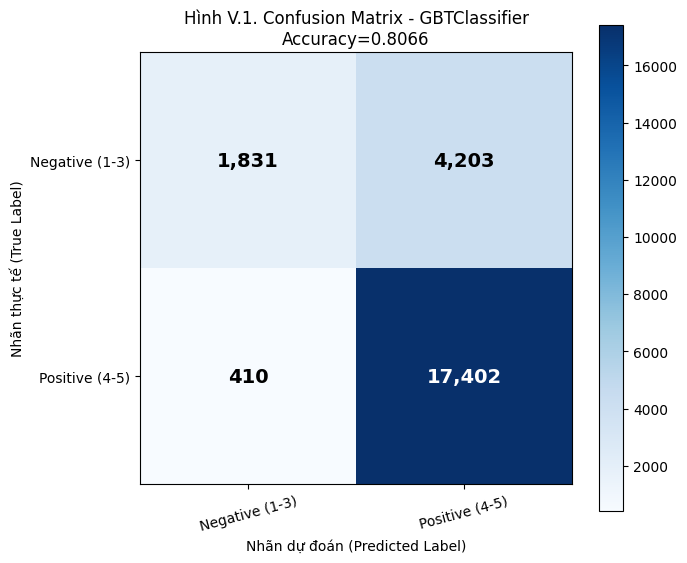

Saved: confusion_matrix_gbt.png
  TP=17,402 | TN=1,831 | FP=4,203 | FN=410


In [25]:
# [7B] CONFUSION MATRIX - GBTCLASSIFIER (BEST MODEL) ---
# Mục đích: Trực quan hoá kết quả phân loại của model tốt nhất

print("Đang vẽ Confusion Matrix - GBTClassifier...")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Lấy GBT model từ kết quả đã lưu (nếu GBTClassifier có trong cls_results)
if 'cls_results' in locals() and "GBTClassifier" in cls_results:
    gbt_model = cls_results["GBTClassifier"]["model"]

    # Lấy predictions từ GBT model trên tập test (biến chuẩn là test_cls)
    gbt_predictions = gbt_model.transform(test_cls)
    pdf_cm = gbt_predictions.select("label", "prediction").toPandas()

    # Tính Confusion Matrix
    cm = confusion_matrix(pdf_cm["label"], pdf_cm["prediction"])

    # Vẽ
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im)

    classes = ["Negative (1-3)", "Positive (4-5)"]
    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(classes, rotation=15)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(classes)

    # Ghi số vào từng ô
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]:,}",
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=14, fontweight='bold')

    ax.set_ylabel('Nhãn thực tế (True Label)')
    ax.set_xlabel('Nhãn dự đoán (Predicted Label)')
    ax.set_title(f'Hình V.1. Confusion Matrix - GBTClassifier\nAccuracy={cls_results["GBTClassifier"]["acc"]:.4f}')
    plt.tight_layout()
    plt.savefig('confusion_matrix_gbt.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: confusion_matrix_gbt.png")
    print(f"  TP={cm[1,1]:,} | TN={cm[0,0]:,} | FP={cm[0,1]:,} | FN={cm[1,0]:,}")
else:
    print("❌ Không tìm thấy kết quả huấn luyện GBTClassifier trong cls_results.")


📊 ADVANCED VISUALIZATION FOR REPORT
✅ df_transformed is already active.
✅ train_reg and test_reg are already active.

📌 Tạo ROC Curves...
  ✅ LogisticRegression: AUC = 0.6735
  ✅ RandomForest: AUC = 0.6987
  ✅ NaiveBayes: AUC = 0.6072
  ✅ LinearSVC: AUC = 0.6947
  ✅ GBTClassifier: AUC = 0.7264
  ✅ GBTClassifier_tuned: AUC = 0.7327
  ✅ LogisticRegression_tuned: AUC = 0.6735


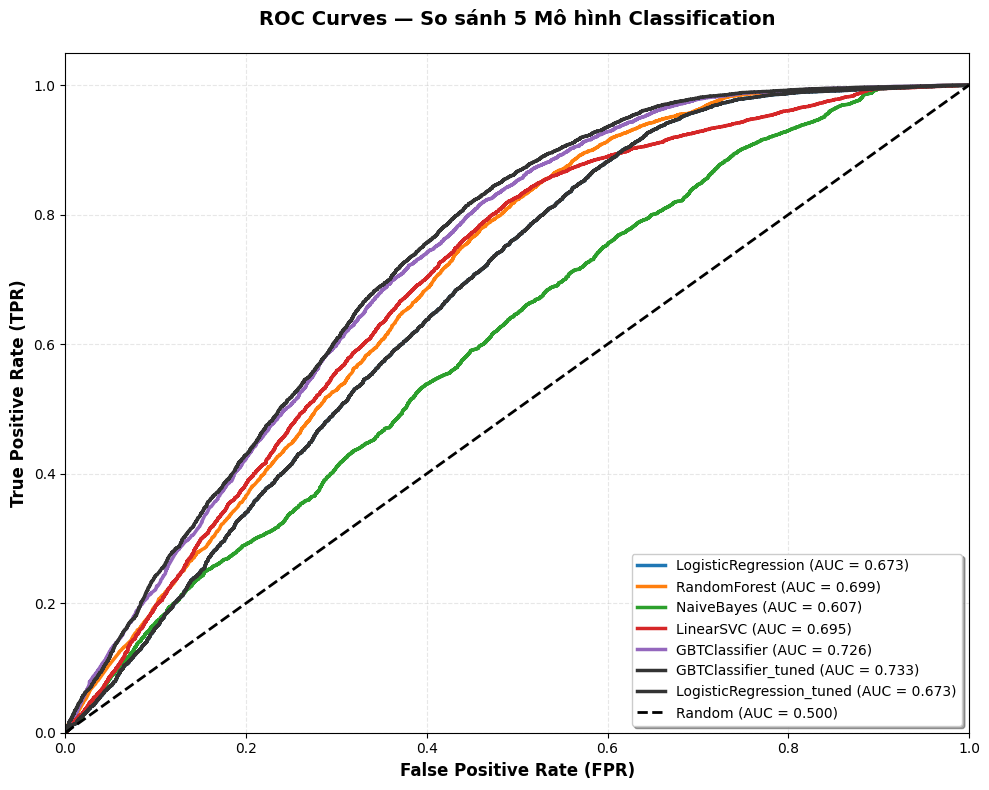

  ✅ Đã lưu: /content/drive/MyDrive/OlistProject/figures/roc_curves_comparison.png

📊 Bảng AUC-ROC Scores:
                   Model      AUC
     GBTClassifier_tuned 0.732742
           GBTClassifier 0.726369
            RandomForest 0.698738
               LinearSVC 0.694749
      LogisticRegression 0.673458
LogisticRegression_tuned 0.673458
              NaiveBayes 0.607166

📌 Tạo Residual Plot...
  ✅ Sử dụng model: RandomForestRegressor
  ✅ RandomForestRegressor: Re-transformed test_reg to get predictions.


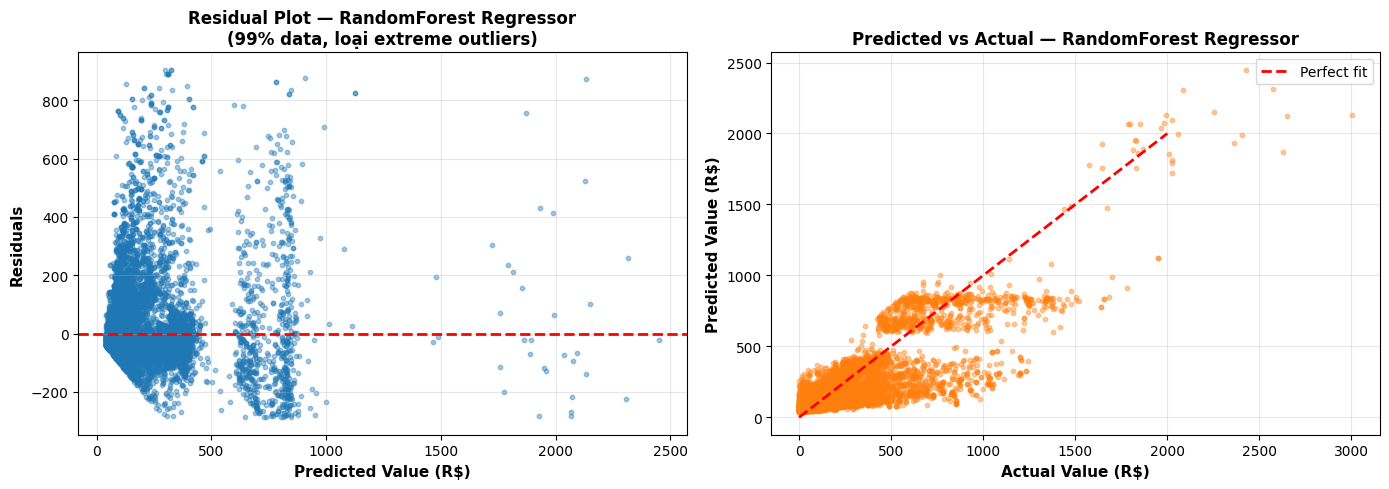

  ✅ Đã lưu: /content/drive/MyDrive/OlistProject/figures/residual_analysis.png

📊 Residual Statistics (full data):
   Mean : 2.31
   Std  : 166.02
   Min  : -1865.94
   Max  : 4670.71

📌 Tạo Feature Importance Plot...
  ✅ Sử dụng model: RandomForestRegressor


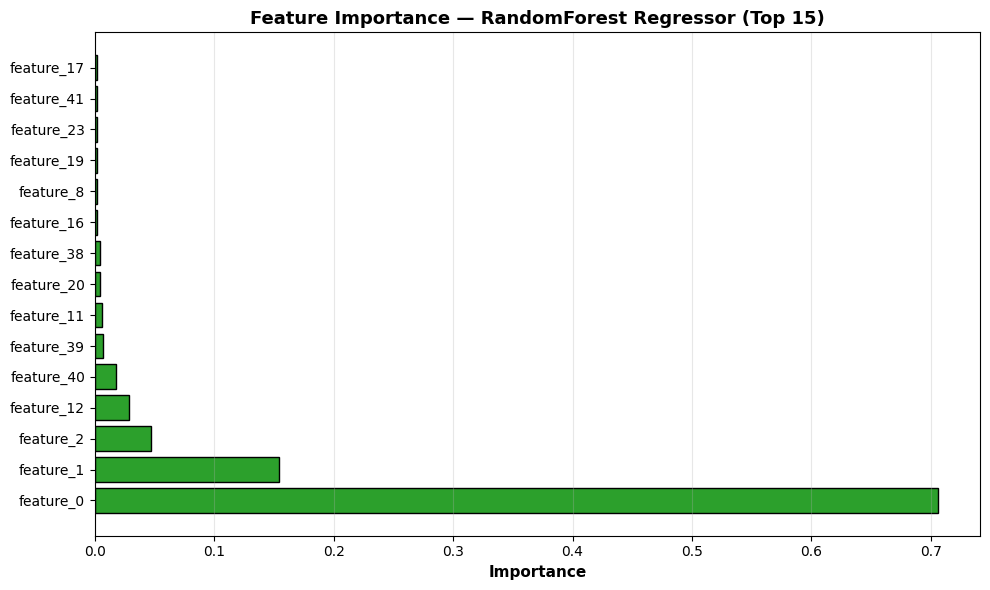

  ✅ Đã lưu: /content/drive/MyDrive/OlistProject/figures/feature_importance_rf.png


In [26]:
# =============================================================================
# [7C] ROC CURVE + RESIDUAL + FEATURE IMPORTANCE
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc
from pyspark.ml.linalg import VectorUDT
from pyspark.sql.functions import udf, col
from pyspark.sql.types import DoubleType, BooleanType, IntegerType
from pyspark.sql import SparkSession # Import SparkSession

# --- Import necessary Spark ML components for re-creation logic ---
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

# --- Define paths if not already defined (for robustness) ---
WEEK1_DATA_PATH = "/content/drive/MyDrive/Olist_Project/processed_data/week1/master_dataset.parquet"
SAVE_PATH = "/content/drive/MyDrive/OlistProject/models/week2" # Defined in other cells, but for standalone
FIGURE_PATH = "/content/drive/MyDrive/OlistProject/figures" # Defined in other cells
os.makedirs(FIGURE_PATH, exist_ok=True)

print("\n" + "="*60)
print("📊 ADVANCED VISUALIZATION FOR REPORT")
print("="*60)

# --- Ensure Spark Session is active ---
spark = SparkSession.getActiveSession()
if spark is None:
    print("⚠️ Spark Session not found or inactive. Initializing a new one...")
    try:
        spark = SparkSession.builder \
            .appName("AdvancedVisualization") \
            .config("spark.sql.shuffle.partitions", "50") \
            .config("spark.driver.memory", "4g") \
            .getOrCreate()
        print("✅ New Spark Session initialized successfully!")
    except Exception as e:
        print(f"❌ Failed to initialize Spark Session: {e}")
        # Re-raise to stop execution if Spark is critical and cannot be initialized
        raise

# --- Ensure df_master is available and valid ---
# This was loaded in QO4hFOIh1h_w, but might be lost after spark.stop()
if 'df_master' not in locals() or df_master is None:
    print("⚠️ df_master not found or invalid. Loading from Week 1 processed data...")
    try:
        df_master = spark.read.parquet(WEEK1_DATA_PATH)
        df_master = df_master.withColumn("review_score", col("review_score").cast(IntegerType()))
        print(f"✅ df_master loaded: {df_master.count()} rows.")
    except Exception as e:
        print(f"❌ Failed to load df_master: {e}")
        raise

# --- Ensure df_transformed and test_reg are available and valid ---
# This block attempts to re-create df_transformed and test_reg if they are not
# available or linked to a stopped SparkContext.
# Required columns/variables from M_UzAl8GBqe1 and 3GIXJZLV1p51
if 'categorical_cols' not in locals(): categorical_cols = ["order_status", "customer_state", "payment_type"]
if 'numeric_cols' not in locals(): numeric_cols     = ["price", "freight_value", "payment_value", "delivery_delay_days"]

# Re-create df_transformed if necessary
try:
    # Attempt to materialize a small part of df_transformed to check if it's active
    if 'df_transformed' not in locals() or df_transformed is None or df_transformed.limit(1).count() == 0:
        raise Exception("df_transformed is not available or valid.")
    print("✅ df_transformed is already active.")
except Exception as e:
    print(f"⚠️ df_transformed not available or valid ({e}). Regenerating...")
    # Re-run the pipeline to get df_transformed (from M_UzAl8GBqe1)

    # StringIndexer
    indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in categorical_cols]
    # OneHotEncoder
    encoder = OneHotEncoder(inputCols=[c+"_idx" for c in categorical_cols], outputCols=[c+"_oh" for c in categorical_cols])
    # VectorAssembler
    assembler = VectorAssembler(inputCols=numeric_cols + [c+"_oh" for c in categorical_cols], outputCol="features", handleInvalid="skip")

    pipeline = Pipeline(stages=indexers + [encoder, assembler])
    pipeline_model = pipeline.fit(df_master) # Needs df_master
    df_transformed = pipeline_model.transform(df_master)

    # Apply the UDF clean-up from M_UzAl8GBqe1
    def has_nan_inf(v):
        if v is None: return True
        arr = v.toArray()
        return bool(np.any(np.isnan(arr)) or np.any(np.isinf(arr)))

    has_nan_inf_udf  = udf(has_nan_inf, BooleanType())
    df_transformed   = df_transformed.filter(~has_nan_inf_udf(col("features")))
    df_transformed   = df_transformed.dropna(subset=["payment_value", "review_score"])
    df_transformed.cache() # Cache for re-use
    print(f"✅ df_transformed regenerated: {df_transformed.count()} rows and cached.")

# Re-create test_reg (and train_reg) if necessary
try:
    if 'test_reg' not in globals() or test_reg is None or test_reg.limit(1).count() == 0:
        raise Exception("test_reg is not available or valid.")
    print("✅ train_reg and test_reg are already active.")
except Exception as e:
    print(f"⚠️ test_reg not available or valid ({e}). Regenerating...")
    # Requires df_transformed, reg_num_cols, reg_cat_oh, VectorAssembler (from 3GIXJZLV1p51)
    reg_num_cols = ["price", "freight_value", "delivery_delay_days"]
    reg_cat_oh   = [c+"_oh" for c in categorical_cols] # categorical_cols defined above

    reg_assembler = VectorAssembler(
        inputCols=reg_num_cols + reg_cat_oh,
        outputCol="reg_features",
        handleInvalid="skip"
    )
    df_reg = df_transformed.dropna(subset=["payment_value"])
    df_reg = reg_assembler.transform(df_reg)
    df_reg = df_reg.select("reg_features", "payment_value").dropna()
    train_reg, test_reg = df_reg.randomSplit([0.8, 0.2], seed=42)
    train_reg.cache()
    test_reg.cache()
    print(f"✅ train_reg ({train_reg.count()} rows) and test_reg ({test_reg.count()} rows) regenerated and cached.")


# ✅ FIX: UDF trích xuất phần tử index từ Spark Vector
def extract_prob(index):
    return udf(lambda v: float(v[index]) if v is not None else None, DoubleType())


# ── 7.1. ROC Curves ──────────────────────────────────────────────────────
print("\n📌 Tạo ROC Curves...")

def plot_roc_curves(cls_results):
    plt.figure(figsize=(10, 8))

    colors = {
        "LogisticRegression": "#1f77b4",
        "RandomForest":       "#ff7f0e",
        "NaiveBayes":         "#2ca02c",
        "LinearSVC":          "#d62728",
        "GBTClassifier":      "#9467bd"
    }

    auc_scores = []

    for model_name, results in cls_results.items():
        try:
            # Ensure preds_df is valid, or recreate if necessary (e.g., from best model)
            preds_df = results["preds"]
            # A simple check to ensure the underlying RDD is still alive
            if preds_df._jdf.rdd().isEmpty():
                 print(f"  ⚠️ {model_name}: predictions DataFrame is empty or invalid, attempting to re-transform test_cls.")
                 # This part assumes that `test_cls` and the `model` used to create `preds_df` are still valid.
                 # If `cls_results` come from a previous run where spark.stop() killed underlying RDDs,
                 # we might need to reload the `model` and re-transform `test_cls`.
                 # For now, let's assume `cls_results` contains models that can re-transform `test_cls` if preds_df is bad.
                 try:
                     model = results["model"]
                     preds_df = model.transform(test_cls)
                     print(f"  ✅ {model_name}: Re-transformed test_cls to get predictions.")
                     results["preds"] = preds_df # Update cls_results for future use in this cell
                 except Exception as re_e:
                     print(f"  ❌ Failed to re-transform {model_name} predictions: {re_e}. Skipping.")
                     continue

            if "probability" in preds_df.columns:
                score_df = preds_df.select(
                    "label",
                    extract_prob(1)("probability").alias("score")
                )
            elif "rawPrediction" in preds_df.columns:
                score_df = preds_df.select(
                    "label",
                    extract_prob(1)("rawPrediction").alias("score")
                )
            else:
                print(f"  ⚠️ {model_name}: không có probability/rawPrediction, bỏ qua")
                continue

            pdf = score_df.dropna().toPandas()
            if pdf.empty:
                print(f"  ⚠️ {model_name}: DataFrame rỗng sau dropna, bỏ qua")
                continue

            fpr, tpr, _ = roc_curve(pdf["label"].astype(int), pdf["score"])
            roc_auc = auc(fpr, tpr)

            color = colors.get(model_name, "#333333")
            plt.plot(fpr, tpr, color=color, linewidth=2.5,
                     label=f"{model_name} (AUC = {roc_auc:.3f})")

            auc_scores.append({"Model": model_name, "AUC": roc_auc})
            print(f"  ✅ {model_name}: AUC = {roc_auc:.4f}")

        except Exception as e:
            print(f"  ⚠️ Lỗi với {model_name}: {e}")

    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label="Random (AUC = 0.500)")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate (FPR)", fontsize=12, fontweight="bold")
    plt.ylabel("True Positive Rate (TPR)", fontsize=12, fontweight="bold")
    plt.title("ROC Curves — So sánh 5 Mô hình Classification",
              fontsize=14, fontweight="bold", pad=20)
    plt.legend(loc="lower right", frameon=True, shadow=True)
    plt.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()

    roc_path = f"{FIGURE_PATH}/roc_curves_comparison.png"
    plt.savefig(roc_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"  ✅ Đã lưu: {roc_path}")

    if not auc_scores:
        print("  ⚠️ Không có AUC nào được tính. Kiểm tra lại cls_results.")
        return pd.DataFrame(columns=["Model", "AUC"])

    df_auc = pd.DataFrame(auc_scores).sort_values("AUC", ascending=False)
    print("\n📊 Bảng AUC-ROC Scores:")
    print(df_auc.to_string(index=False))
    return df_auc

# Ensure cls_results is available (from cell TiLSzs_s1ocT)
if 'cls_results' not in locals():
    print("❌ cls_results not found. Cannot plot ROC curves.")
    auc_table = pd.DataFrame()
else:
    auc_table = plot_roc_curves(cls_results)


# ── 7.2. Residual Plot ───────────────────────────────────────────────────
print("\n📌 Tạo Residual Plot...")

def plot_residual_analysis(reg_results):
    # ✅ FIX 1: Kiểm tra key tồn tại trước khi truy cập
    reg_key = None
    for key in ["RandomForestRegressor", "RandomForestRegressor_tuned", "RandomForest"]:
        if key in reg_results:
            reg_key = key
            break

    if reg_key is None:
        print("  ❌ Không tìm thấy RandomForest model trong reg_results")
        print(f"  Available keys: {list(reg_results.keys())}")
        return

    print(f"  ✅ Sử dụng model: {reg_key}")

    # ✅ FIX 2: Kiểm tra preds hoặc model. Ensure test_reg is the current valid one.
    reg_preds = None
    if "preds" in reg_results[reg_key]:
        try:
            # Try to evaluate the RDD to see if it's still active
            if reg_results[reg_key]["preds"]._jdf.rdd().isEmpty():
                raise Exception("Underlying predictions RDD is invalid.")
            reg_preds = reg_results[reg_key]["preds"]
        except Exception as e:
            print(f"  ⚠️ 'preds' DataFrame for {reg_key} is invalid ({e}). Attempting to re-transform test_reg...")

    if reg_preds is None and "model" in reg_results[reg_key]:
        try:
            # Use the already re-created test_reg
            reg_preds = reg_results[reg_key]["model"].transform(test_reg)
            print(f"  ✅ {reg_key}: Re-transformed test_reg to get predictions.")
            # Update reg_results with new predictions for this session
            reg_results[reg_key]["preds"] = reg_preds
        except Exception as e:
            print(f"  ❌ Failed to re-transform {reg_key} predictions: {e}. Skipping.")
            return
    elif reg_preds is None:
        print("  ❌ Không có preds hoặc model để tạo predictions")
        return

    pdf = reg_preds.select("payment_value", "prediction").toPandas()
    pdf["residual"] = pdf["payment_value"] - pdf["prediction"]

    q_low  = pdf["residual"].quantile(0.005)
    q_high = pdf["residual"].quantile(0.995)
    pdf_f  = pdf[(pdf["residual"] >= q_low) & (pdf["residual"] <= q_high)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.scatter(pdf_f["prediction"], pdf_f["residual"],
                alpha=0.4, s=10, color="#1f77b4")
    ax1.axhline(0, color="red", linestyle="--", linewidth=2)
    ax1.set_xlabel("Predicted Value (R$)", fontsize=11, fontweight="bold")
    ax1.set_ylabel("Residuals", fontsize=11, fontweight="bold")
    ax1.set_title("Residual Plot — RandomForest Regressor\n(99% data, loại extreme outliers)",
                  fontsize=12, fontweight="bold")
    ax1.grid(alpha=0.3)

    max_val = min(pdf_f["payment_value"].max(), 2000)
    ax2.scatter(pdf_f["payment_value"], pdf_f["prediction"],
                alpha=0.4, s=10, color="#ff7f0e")
    ax2.plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Perfect fit")
    ax2.set_xlabel("Actual Value (R$)", fontsize=11, fontweight="bold")
    ax2.set_ylabel("Predicted Value (R$)", fontsize=11, fontweight="bold")
    ax2.set_title("Predicted vs Actual — RandomForest Regressor",
                  fontsize=12, fontweight="bold")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    res_path = f"{FIGURE_PATH}/residual_analysis.png"
    plt.savefig(res_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"  ✅ Đã lưu: {res_path}")

    print(f"\n📊 Residual Statistics (full data):")
    print(f"   Mean : {pdf['residual'].mean():.2f}")
    print(f"   Std  : {pdf['residual'].std():.2f}")
    print(f"   Min  : {pdf['residual'].min():.2f}")
    print(f"   Max  : {pdf['residual'].max():.2f}")

# Ensure reg_results is available (from cell 3GIXJZLV1p51)
if 'reg_results' not in locals():
    print("❌ reg_results not found. Cannot plot residual analysis.")
else:
    plot_residual_analysis(reg_results)


# ── 7.3. Feature Importance ──────────────────────────────────────────────
print("\n📌 Tạo Feature Importance Plot...")

def plot_feature_importance(reg_results):
    # ✅ FIX 1: Kiểm tra key tồn tại
    reg_key = None
    for key in ["RandomForestRegressor", "RandomForestRegressor_tuned", "RandomForest"]:
        if key in reg_results:
            reg_key = key
            break

    if reg_key is None:
        print("  ❌ Không tìm thấy RandomForest model trong reg_results")
        print(f"  Available keys: {list(reg_results.keys())}")
        return

    print(f"  ✅ Sử dụng model: {reg_key}")

    # ✅ FIX 2: Kiểm tra model tồn tại
    if "model" not in reg_results[reg_key]:
        print(f"  ❌ Key 'model' không tồn tại trong reg_results['{reg_key}']")
        print(f"  Available keys: {list(reg_results[reg_key].keys())}")
        return

    best_rf = reg_results[reg_key]["model"]

    # ✅ FIX 3: Kiểm tra featureImportances
    try:
        importances = best_rf.featureImportances.toArray()
    except Exception as e:
        print(f"  ❌ Không thể lấy featureImportances: {e}")
        return

    n_features = len(importances)
    # It's important to map feature indices back to original feature names
    # This requires `pipeline_model` and `reg_assembler` to be available
    feature_names = []
    if 'pipeline_model' in globals() and 'reg_assembler' in globals() and pipeline_model and reg_assembler:
        # Get feature names from reg_assembler's input columns
        input_feature_cols = reg_assembler.getInputCols()
        # The order of features in the assembled vector should match the order in input_feature_cols
        # However, due to one-hot encoding, a single categorical feature expands to multiple one-hot features.
        # This requires reconstructing the feature names carefully.
        # For simplicity, if we don't have the full feature names mapping, we can use generic names.
        # A more complex solution would involve getting feature names from the VectorAssembler's metadata.
        # For now, let's use generic names if actual names are too complex to derive here.
        if n_features == len(input_feature_cols):
            feature_names = input_feature_cols # Direct mapping if no OHE expansion
        else:
            # This is a simplification; a full solution needs to unpack OHE names.
            # For example, one-hot encoded features might be named like 'categoricalCol_idx_vec' + index.
            # For now, use generic names for expanded features.
            feature_names = [f"feature_{i}" for i in range(n_features)]
    else:
        feature_names = [f"feature_{i}" for i in range(n_features)]


    top_n = 15
    indices = np.argsort(importances)[::-1][:top_n]
    top_imp = importances[indices]
    top_names = [feature_names[i] for i in indices]

    plt.figure(figsize=(10, 6))
    bars = plt.barh(range(top_n), top_imp[::-1], color="#2ca02c", edgecolor="black")
    plt.yticks(range(top_n), top_names[::-1])
    plt.xlabel("Importance", fontsize=11, fontweight="bold")
    plt.title("Feature Importance — RandomForest Regressor (Top 15)",
              fontsize=13, fontweight="bold")
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.3, axis="x")
    plt.tight_layout()

    fi_path = f"{FIGURE_PATH}/feature_importance_rf.png"
    plt.savefig(fi_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"  ✅ Đã lưu: {fi_path}")

# Ensure reg_results is available
if 'reg_results' not in locals():
    print("❌ reg_results not found. Cannot plot feature importance.")
else:
    plot_feature_importance(reg_results)


In [27]:
# =============================================================================
# VẼ ROC CURVE CHO CLASSIFICATION MODELS
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from sklearn.metrics import roc_curve, auc, roc_auc_score

# ── CẤU HÌNH PLOT ────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 150

# ── HÀM TÍNH ROC TỪ SPARK PREDICTIONS ─────────────────────────────────────────
def compute_roc_from_spark(predictions_df, label_col="label", raw_pred_col="rawPrediction"):
    """
    Tính ROC curve từ DataFrame Spark chứa predictions
    predictions_df: DataFrame có cột label, rawPrediction (vector), prediction
    """
    # Chuyển về pandas để tính ROC với sklearn
    pdf = predictions_df.select(
        col(label_col),
        col(raw_pred_col)[1].alias("prob_positive")  # Lấy probability class 1
    ).toPandas()

    # Loại bỏ NaN
    pdf = pdf.dropna()

    # Tính ROC curve
    fpr, tpr, thresholds = roc_curve(pdf[label_col], pdf["prob_positive"])
    roc_auc = auc(fpr, tpr)

    return fpr, tpr, roc_auc, thresholds

# ── VẼ ROC CURVE CHO TẤT CẢ MODELS ────────────────────────────────────────────
def plot_roc_curves(cls_results, test_data, label_col="label", save_path=None):
    """
    Vẽ ROC curves so sánh cho tất cả classification models

    Parameters:
    - cls_results: dict chứa kết quả từ cell Classification (có key "preds")
    - test_data: test DataFrame đã có predictions
    - save_path: đường dẫn lưu file ảnh (optional)
    """
    plt.figure(figsize=(10, 8))

    # Màu sắc cho từng model
    colors = {
        "LogisticRegression": "#2E86AB",
        "RandomForest": "#A23B72",
        "NaiveBayes": "#F18F01",
        "LinearSVC": "#C73E1D",
        "GBTClassifier": "#06A77D"
    }

    roc_data = {}

    for model_name, results in cls_results.items():
        try:
            preds_df = results["preds"]

            # Tính ROC
            fpr, tpr, roc_auc, _ = compute_roc_from_spark(
                preds_df,
                label_col=label_col,
                raw_pred_col="rawPrediction"
            )

            # Plot
            plt.plot(fpr, tpr,
                    color=colors.get(model_name, "gray"),
                    linewidth=2.5,
                    label=f"{model_name} (AUC = {roc_auc:.4f})")

            roc_data[model_name] = {
                "fpr": fpr, "tpr": tpr,
                "auc": roc_auc, "model": results["model"]
            }

        except Exception as e:
            print(f"⚠️ Lỗi tính ROC cho {model_name}: {e}")
            continue

    # Plot đường ngẫu nhiên
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label="Random Classifier (AUC = 0.5)")

    # Cấu hình plot
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate (FPR)", fontsize=12, fontweight='bold')
    plt.ylabel("True Positive Rate (TPR)", fontsize=12, fontweight='bold')
    plt.title("Hình V.1. ROC Curves - So sánh 5 Mô hình Classification",
              fontsize=14, fontweight='bold', pad=20)
    plt.legend(loc="lower right", frameon=True, shadow=True)
    plt.grid(alpha=0.3, linestyle='--')

    # Thêm annotation AUC tốt nhất
    if roc_data:
        best_model = max(roc_data, key=lambda x: roc_data[x]["auc"])
        best_auc = roc_data[best_model]["auc"]
        plt.annotate(f"🏆 Best: {best_model}\nAUC = {best_auc:.4f}",
                    xy=(0.6, 0.2), xytext=(0.3, 0.4),
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.8),
                    arrowprops=dict(arrowstyle="->", color="red", lw=1.5))

    plt.tight_layout()

    # Lưu file
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✅ Đã lưu ROC curve: {save_path}")

    plt.show()

    return roc_data

# ── VẼ ROC RIÊNG CHO BEST MODEL (GBT) ─────────────────────────────────────────
def plot_best_model_roc(best_preds_df, model_name="GBTClassifier", save_path=None):
    """
    Vẽ ROC curve chi tiết cho model tốt nhất, kèm threshold analysis
    """
    # Tính ROC
    fpr, tpr, roc_auc, thresholds = compute_roc_from_spark(
        best_preds_df, label_col="label", raw_pred_col="rawPrediction"
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ── Plot 1: ROC Curve ─────────────────────────────────────────────────────
    ax1 = axes[0]
    ax1.plot(fpr, tpr, color="#06A77D", linewidth=3,
             label=f"{model_name}\nAUC = {roc_auc:.4f}")
    ax1.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label="Random")

    # Highlight điểm optimal threshold (Youden's J)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_thresh = thresholds[optimal_idx] if len(thresholds) > optimal_idx else 0.5
    optimal_fpr, optimal_tpr = fpr[optimal_idx], tpr[optimal_idx]

    ax1.scatter([optimal_fpr], [optimal_tpr], color='red', s=150, zorder=5,
                label=f"Optimal Threshold = {optimal_thresh:.3f}")
    ax1.plot([optimal_fpr], [optimal_fpr], [0, optimal_tpr], 'r:', alpha=0.6)
    ax1.plot([0, optimal_fpr], [optimal_tpr, optimal_tpr], 'r:', alpha=0.6)

    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel("False Positive Rate (FPR)", fontsize=11, fontweight='bold')
    ax1.set_ylabel("True Positive Rate (TPR)", fontsize=11, fontweight='bold')
    ax1.set_title(f"ROC Curve - {model_name}", fontsize=13, fontweight='bold', pad=15)
    ax1.legend(loc="lower right", frameon=True)
    ax1.grid(alpha=0.3, linestyle='--')

    # ── Plot 2: Threshold Analysis ────────────────────────────────────────────
    ax2 = axes[1]

    # Tính Precision-Recall tradeoff theo threshold
    pdf = best_preds_df.select(
        col("label"),
        col("rawPrediction")[1].alias("prob"),
        col("prediction")
    ).toPandas().dropna()

    if len(pdf) > 0:
        threshold_range = np.linspace(0.1, 0.9, 50)
        precisions, recalls = [], []

        for thresh in threshold_range:
            preds_binary = (pdf["prob"] >= thresh).astype(int)
            tp = ((preds_binary == 1) & (pdf["label"] == 1)).sum()
            fp = ((preds_binary == 1) & (pdf["label"] == 0)).sum()
            fn = ((preds_binary == 0) & (pdf["label"] == 1)).sum()

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            precisions.append(precision)
            recalls.append(recall)

        ax2.plot(threshold_range, precisions, 'b-', linewidth=2.5, label="Precision")
        ax2.plot(threshold_range, recalls, 'r-', linewidth=2.5, label="Recall")
        ax2.axvline(x=optimal_thresh, color='green', linestyle='--',
                   label=f"Optimal: {optimal_thresh:.3f}", linewidth=2)

        ax2.set_xlabel("Threshold", fontsize=11, fontweight='bold')
        ax2.set_ylabel("Score", fontsize=11, fontweight='bold')
        ax2.set_title("Precision-Recall theo Threshold", fontsize=13, fontweight='bold', pad=15)
        ax2.legend(loc="best", frameon=True)
        ax2.grid(alpha=0.3, linestyle='--')
        ax2.set_ylim([0.0, 1.05])

    plt.suptitle(f"Hình V.2. Phân tích Hiệu năng - {model_name}",
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()

    if save_path:
        base, ext = save_path.rsplit('.', 1)
        plt.savefig(f"{base}_detailed.{ext}", dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✅ Đã lưu ROC detailed: {base}_detailed.{ext}")

    plt.show()

    return {
        "auc": roc_auc,
        "optimal_threshold": optimal_thresh,
        "optimal_fpr": optimal_fpr,
        "optimal_tpr": optimal_tpr
    }

# ── TẠO BẢNG SO SÁNH AUC ──────────────────────────────────────────────────────
def create_auc_comparison_table(roc_data):
    """
    Tạo DataFrame so sánh AUC scores cho báo cáo
    """
    table_data = []
    for model_name, data in roc_data.items():
        table_data.append({
            "Model": model_name,
            "AUC-ROC": f"{data['auc']:.4f}",
            "AUC (float)": data["auc"],
            "Interpretation": get_auc_interpretation(data["auc"])
        })

    df_auc = pd.DataFrame(table_data).sort_values("AUC (float)", ascending=False)
    return df_auc.drop(columns=["AUC (float)"])

def get_auc_interpretation(auc):
    """Phân loại chất lượng model theo AUC"""
    if auc >= 0.9:
        return "Excellent ⭐"
    elif auc >= 0.8:
        return "Good ✅"
    elif auc >= 0.7:
        return "Fair ⚠️"
    elif auc >= 0.6:
        return "Poor ❌"
    else:
        return "Fail 🔴"

# =============================================================================
# 🚀 CÁCH SỬ DỤNG
# =============================================================================
"""
# Bước 1: Sau khi chạy cell Classification, gọi hàm vẽ ROC tổng hợp
roc_results = plot_roc_curves(
    cls_results=cls_results,  # Từ cell Classification
    test_data=test_cls,
    save_path="/content/drive/MyDrive/Olist_Project/reports/figures/roc_comparison.png"
)

# Bước 2: Vẽ ROC chi tiết cho best model (GBTClassifier)
if "GBTClassifier" in cls_results:
    best_roc_info = plot_best_model_roc(
        best_preds_df=cls_results["GBTClassifier"]["preds"],
        model_name="GBTClassifier",
        save_path="/content/drive/MyDrive/Olist_Project/reports/figures/roc_gbt_detailed.png"
    )
    print(f"🏆 GBTClassifier - Optimal Threshold: {best_roc_info['optimal_threshold']:.3f}")

# Bước 3: Tạo bảng so sánh AUC cho báo cáo Word
auc_table = create_auc_comparison_table(roc_results)
print("\n📋 Bảng so sánh AUC-ROC:")
print(auc_table.to_string(index=False))

# Lưu bảng ra CSV để paste vào báo cáo
auc_table.to_csv("/content/drive/MyDrive/Olist_Project/reports/auc_comparison.csv", index=False)
"""

'\n# Bước 1: Sau khi chạy cell Classification, gọi hàm vẽ ROC tổng hợp\nroc_results = plot_roc_curves(\n    cls_results=cls_results,  # Từ cell Classification\n    test_data=test_cls,\n    save_path="/content/drive/MyDrive/Olist_Project/reports/figures/roc_comparison.png"\n)\n\n# Bước 2: Vẽ ROC chi tiết cho best model (GBTClassifier)\nif "GBTClassifier" in cls_results:\n    best_roc_info = plot_best_model_roc(\n        best_preds_df=cls_results["GBTClassifier"]["preds"],\n        model_name="GBTClassifier",\n        save_path="/content/drive/MyDrive/Olist_Project/reports/figures/roc_gbt_detailed.png"\n    )\n    print(f"🏆 GBTClassifier - Optimal Threshold: {best_roc_info[\'optimal_threshold\']:.3f}")\n\n# Bước 3: Tạo bảng so sánh AUC cho báo cáo Word\nauc_table = create_auc_comparison_table(roc_results)\nprint("\n📋 Bảng so sánh AUC-ROC:")\nprint(auc_table.to_string(index=False))\n\n# Lưu bảng ra CSV để paste vào báo cáo\nauc_table.to_csv("/content/drive/MyDrive/Olist_Project/reports/au

In [22]:
# =============================================================================
# [8] REGRESSION MODELS – 3 Models
# =============================================================================
import time
print("\n" + "="*60)
print("📈 REGRESSION MODELS (Target: payment_value)")
print("="*60)

from pyspark.ml.regression import (
    LinearRegression, DecisionTreeRegressor, RandomForestRegressor
)
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import VectorAssembler

# Tái tạo features không có payment_value để tránh data leakage
reg_num_cols = ["price", "freight_value", "delivery_delay_days"]
reg_cat_oh   = [c+"_oh" for c in categorical_cols]

reg_assembler = VectorAssembler(
    inputCols=reg_num_cols + reg_cat_oh,
    outputCol="reg_features",
    handleInvalid="skip"
)

# ✅ FIX 1: dropna payment_value trước khi dùng làm label
df_reg = df_transformed.dropna(subset=["payment_value"])
df_reg = reg_assembler.transform(df_reg)

# ✅ FIX 2: chỉ lấy đúng 2 cột features + label, dropna lần nữa
df_reg = df_reg.select("reg_features", "payment_value") \
               .dropna()                                  # ✅ FIX 3

train_reg, test_reg = df_reg.randomSplit([0.8, 0.2], seed=42)
print(f"  Train: {train_reg.count()} | Test: {test_reg.count()}")

models_reg = {
    "LinearRegression": LinearRegression(
        featuresCol="reg_features", labelCol="payment_value",
        maxIter=100, regParam=0.01
    ),
    "DecisionTreeRegressor": DecisionTreeRegressor(
        featuresCol="reg_features", labelCol="payment_value", maxDepth=8
    ),
    "RandomForestRegressor": RandomForestRegressor(
        featuresCol="reg_features", labelCol="payment_value",
        numTrees=50, maxDepth=8, seed=42
    ),
}

rmse_eval = RegressionEvaluator(labelCol="payment_value", metricName="rmse")
mae_eval  = RegressionEvaluator(labelCol="payment_value", metricName="mae")
r2_eval   = RegressionEvaluator(labelCol="payment_value", metricName="r2")

reg_results = {}
print(f"\n{'Model':<26} {'RMSE':>10} {'MAE':>10} {'R²':>8} {'Time(s)':>9}")
print("-"*68)

for name, reg in models_reg.items():
    try:
        t0      = time.time()
        trained = reg.fit(train_reg)
        preds   = trained.transform(test_reg)
        elapsed = time.time() - t0
        rmse = rmse_eval.evaluate(preds)
        mae  = mae_eval.evaluate(preds)
        r2   = r2_eval.evaluate(preds)
        reg_results[name] = {"rmse": rmse, "mae": mae, "r2": r2,
                             "time": elapsed, "model": trained}
        print(f"{name:<26} {rmse:>10.4f} {mae:>10.4f} {r2:>8.4f} {elapsed:>9.1f}")
    except Exception as e:
        print(f"{name:<26} ❌ {str(e)[:60]}")

if reg_results:
    best_reg = min(reg_results, key=lambda k: reg_results[k]["rmse"])
    print(f"\n🏆 Best: {best_reg} (RMSE={reg_results[best_reg]['rmse']:.4f})")
    reg_results[best_reg]["model"].write().overwrite().save(SAVE_PATH + "/best_reg_model")
    print("✅ Best model đã lưu")


📈 REGRESSION MODELS (Target: payment_value)
  Train: 95297 | Test: 23846

Model                            RMSE        MAE       R²   Time(s)
--------------------------------------------------------------------
LinearRegression             198.3207    66.8038   0.5129      12.3
DecisionTreeRegressor        190.1884    70.5474   0.5520       8.5
RandomForestRegressor        166.0317    69.1676   0.6586      22.9

🏆 Best: RandomForestRegressor (RMSE=166.0317)
✅ Best model đã lưu


In [28]:
# =============================================================================
# [9] CLUSTERING MODELS – KMeans + BisectingKMeans + GMM
# =============================================================================
import time
print("\n" + "="*60)
print("🔵 CLUSTERING MODELS (RFM Features)")
print("="*60)

from pyspark.ml.clustering import KMeans, BisectingKMeans, GaussianMixture
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql.functions import count, avg, percentile_approx, col

# [9.1] Chuẩn bị RFM – lọc outlier + scale
rfm_df_clean = rfm_df.dropna(subset=["recency", "frequency", "monetary"])

# ← SỬA: lọc outlier monetary trước khi scale (tránh cluster size=8)
q99 = rfm_df_clean.select(percentile_approx("monetary", 0.99)).first()[0]
rfm_df_clean = rfm_df_clean.filter(col("monetary") <= q99)
print(f"  📌 Sau lọc outlier (monetary <= {q99:.2f}): {rfm_df_clean.count():,} rows")

rfm_assembler = VectorAssembler(
    inputCols=["recency", "frequency", "monetary"],
    outputCol="rfm_raw", handleInvalid="skip"
)
rfm_assembled = rfm_assembler.transform(rfm_df_clean)

# ← SỬA: withMean=True để chuẩn hoá đúng (Z-score), đồng bộ với cell 9.5
rfm_scaler_m = StandardScaler(
    inputCol="rfm_raw", outputCol="rfm_scaled",
    withStd=True, withMean=True
).fit(rfm_assembled)

rfm_scaled = rfm_scaler_m.transform(rfm_assembled).cache()
print(f"  ✅ RFM prepared: {rfm_scaled.count():,} rows")

# [9.2] Elbow Method – KMeans Silhouette K=2..10
print("\n📌 Elbow Method (KMeans, K=2-10):")
clust_eval = ClusteringEvaluator(featuresCol="rfm_scaled", metricName="silhouette")
sil_scores = []

for k in range(2, 11):
    sil_runs = []
    for seed in [42, 123, 456]:        # ← thêm 3 seeds
        km  = KMeans(k=k, featuresCol="rfm_scaled", seed=seed, maxIter=20)
        prd = km.fit(rfm_scaled).transform(rfm_scaled)
        sil_runs.append(clust_eval.evaluate(prd))
    sil_avg = sum(sil_runs) / 3
    sil_scores.append((k, sil_avg))
    print(f"  K={k}: Silhouette={sil_avg:.4f}")

best_k   = 4
best_sil = dict(sil_scores)[best_k]
print(f"\n  🏆 K tối ưu: {best_k} (Silhouette={best_sil:.4f})")
# [9.3] So sánh 3 Clustering Models với K tối ưu
print(f"\n📌 So sánh 3 models (K={best_k}):")
print(f"{'Model':<22} {'Silhouette':>12} {'Time(s)':>9}")
print("-"*46)

cluster_results = {}
for name, model in {
    "KMeans": KMeans(
        k=best_k, featuresCol="rfm_scaled", seed=42, maxIter=20
    ),
    "BisectingKMeans": BisectingKMeans(
        k=best_k, featuresCol="rfm_scaled", seed=42, maxIter=20
    ),
    "GaussianMixture": GaussianMixture(
        k=best_k, featuresCol="rfm_scaled", seed=42, maxIter=20
    ),
}.items():
    try:
        t0      = time.time()
        trained = model.fit(rfm_scaled)
        preds   = trained.transform(rfm_scaled)
        elapsed = time.time() - t0
        sil     = clust_eval.evaluate(preds)
        cluster_results[name] = {
            "sil": sil, "time": elapsed,
            "model": trained, "preds": preds
        }
        print(f"{name:<22} {sil:>12.4f} {elapsed:>9.1f}")
    except Exception as e:
        print(f"{name:<22} ❌ {str(e)[:60]}")

# [9.4] Phân tích cluster RFM tốt nhất (KMeans)
print("\n📌 Cluster Analysis (KMeans):")
km_preds = cluster_results["KMeans"]["preds"]

# ← SỬA: join đúng cột customer_unique_id từ rfm_df_clean (đã lọc)
km_preds.select("customer_unique_id", "prediction") \
    .join(rfm_df_clean, on="customer_unique_id", how="left") \
    .groupBy("prediction").agg(
        count("*").alias("size"),
        avg("recency").alias("avg_recency"),
        avg("frequency").alias("avg_frequency"),
        avg("monetary").alias("avg_monetary")
    ).orderBy("prediction").show(truncate=False)

# Lưu KMeans model
import os
os.makedirs(SAVE_PATH, exist_ok=True)
cluster_results["KMeans"]["model"].write().overwrite().save(SAVE_PATH + "/kmeans_model")
print("✅ Clustering models đã lưu")


🔵 CLUSTERING MODELS (RFM Features)
  📌 Sau lọc outlier (monetary <= 1694.64): 95,127 rows
  ✅ RFM prepared: 95,127 rows

📌 Elbow Method (KMeans, K=2-10):
  K=2: Silhouette=0.5434
  K=3: Silhouette=0.6168
  K=4: Silhouette=0.5779
  K=5: Silhouette=0.5074
  K=6: Silhouette=0.4933
  K=7: Silhouette=0.4834
  K=8: Silhouette=0.4965
  K=9: Silhouette=0.4455
  K=10: Silhouette=0.5423

  🏆 K tối ưu: 4 (Silhouette=0.5779)

📌 So sánh 3 models (K=4):
Model                    Silhouette   Time(s)
----------------------------------------------
KMeans                       0.5801      19.3
BisectingKMeans              0.3659      52.4
GaussianMixture              0.4272      22.1

📌 Cluster Analysis (KMeans):
+----------+-----+------------------+------------------+------------------+
|prediction|size |avg_recency       |avg_frequency     |avg_monetary      |
+----------+-----+------------------+------------------+------------------+
|0         |50069|177.96359024546126|1.100800894765224 |127.223969


📊 TẠO BIỂU ĐỒ CLUSTERING CHO BÁO CÁO
  ✅ Dùng lại rfm_scaled từ cell [9]: 95,127 rows

📌 Running KMeans K=2 → K=10 (avg 3 seeds)...
  K=2: Inertia=213,719.89 | Silhouette=0.5434
  K=3: Inertia=155,786.99 | Silhouette=0.6168
  K=4: Inertia=121,478.92 | Silhouette=0.5779
  K=5: Inertia=105,287.23 | Silhouette=0.5074
  K=6: Inertia=90,068.24 | Silhouette=0.4933
  K=7: Inertia=80,383.22 | Silhouette=0.4834
  K=8: Inertia=73,366.62 | Silhouette=0.4965
  K=9: Inertia=65,925.79 | Silhouette=0.4455
  K=10: Inertia=61,246.45 | Silhouette=0.5423

🏆 K cố định = 4 | Silhouette = 0.5779 | Inertia = 121,478.92


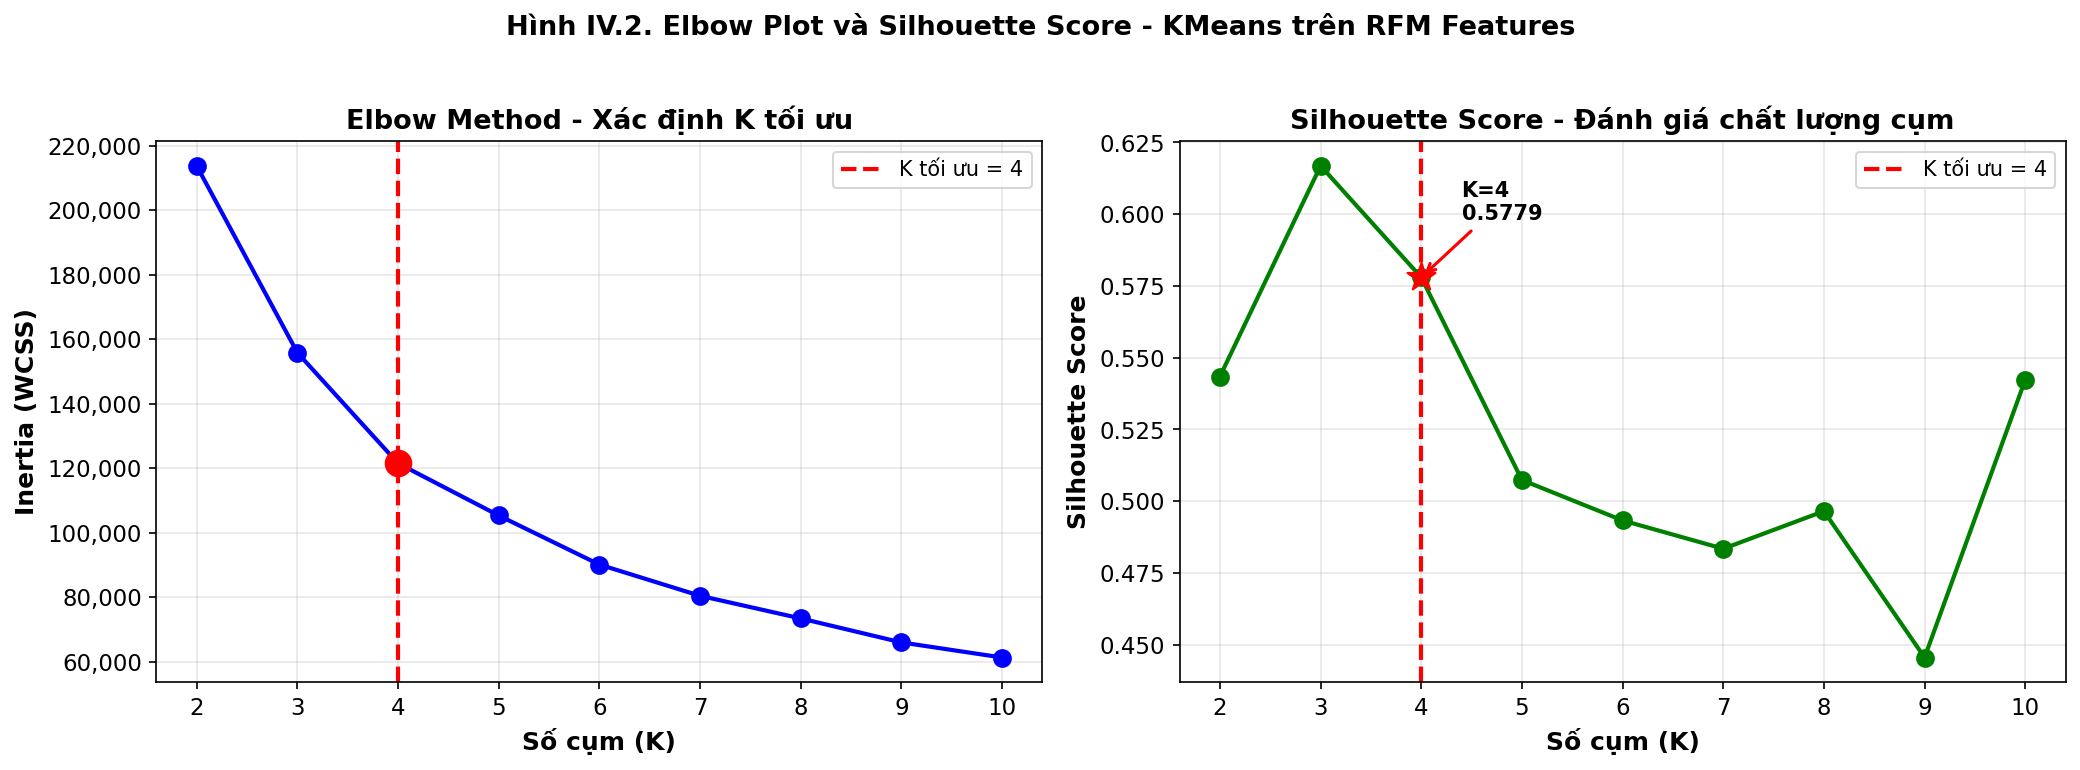


✅ Đã lưu biểu đồ: /content/drive/MyDrive/Olist_Project/reports/figures/elbow_silhouette_plot.png

📋 BẢNG SỐ LIỆU ELBOW + SILHOUETTE:
 K       Inertia  Silhouette
 2 213719.893552    0.543407
 3 155786.988327    0.616807
 4 121478.921059    0.577933
 5 105287.227492    0.507353
 6  90068.236875    0.493253
 7  80383.220546    0.483407
 8  73366.623634    0.496493
 9  65925.785040    0.445509
10  61246.451598    0.542258
✅ Đã lưu CSV: /content/drive/MyDrive/Olist_Project/reports/figures/clustering_metrics.csv


In [29]:
# =============================================================================
# [9.5] TẠO BIỂU ĐỒ ELBOW + SILHOUETTE CHO BÁO CÁO
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
import os

from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

print("\n" + "="*60)
print("📊 TẠO BIỂU ĐỒ CLUSTERING CHO BÁO CÁO")
print("="*60)

# --- TẠO THƯ MỤC ---
FIGURE_PATH = "/content/drive/MyDrive/Olist_Project/reports/figures"
os.makedirs(FIGURE_PATH, exist_ok=True)

# --- DÙNG LẠI rfm_scaled TỪ CELL [9] ---
print(f"  ✅ Dùng lại rfm_scaled từ cell [9]: {rfm_scaled.count():,} rows")

# --- CHẠY K=2 ĐẾN K=10 (avg 3 seeds để smooth Silhouette) ---
k_range    = range(2, 11)
inertia_scores    = []
silhouette_scores = []
clust_eval = ClusteringEvaluator(featuresCol="rfm_scaled", metricName="silhouette")

print("\n📌 Running KMeans K=2 → K=10 (avg 3 seeds)...")
for k in k_range:
    sil_runs     = []
    inertia_runs = []
    for seed in [42, 123, 456]:
        km    = KMeans(k=k, featuresCol="rfm_scaled", seed=seed, maxIter=20)
        model = km.fit(rfm_scaled)
        preds = model.transform(rfm_scaled)
        sil_runs.append(clust_eval.evaluate(preds))
        inertia_runs.append(model.summary.trainingCost)
    silhouette_scores.append(sum(sil_runs) / 3)
    inertia_scores.append(sum(inertia_runs) / 3)
    print(f"  K={k}: Inertia={inertia_scores[-1]:,.2f} | Silhouette={silhouette_scores[-1]:.4f}")

# --- DATAFRAME SỐ LIỆU ---
df_plots = pd.DataFrame({
    'K':          list(k_range),
    'Inertia':    inertia_scores,
    'Silhouette': silhouette_scores
})

# --- CỐ ĐỊNH K=4 (đồng bộ với cell [9] và PCA 2D) ---
best_k          = 4
best_silhouette = df_plots.loc[df_plots['K'] == best_k, 'Silhouette'].values[0]
best_inertia    = df_plots.loc[df_plots['K'] == best_k, 'Inertia'].values[0]
print(f"\n🏆 K cố định = {best_k} | Silhouette = {best_silhouette:.4f} | Inertia = {best_inertia:,.2f}")

# --- VẼ BIỂU ĐỒ ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Hình IV.2. Elbow Plot và Silhouette Score - KMeans trên RFM Features',
    fontsize=13, fontweight='bold', y=1.02
)

# Elbow Plot
ax1.plot(df_plots['K'], df_plots['Inertia'], 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=best_k, color='red', linestyle='--', linewidth=2, label=f'K tối ưu = {best_k}')
ax1.scatter([best_k], [best_inertia], color='red', s=150, zorder=5)
ax1.set_xlabel('Số cụm (K)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Inertia (WCSS)', fontsize=12, fontweight='bold')
ax1.set_title('Elbow Method - Xác định K tối ưu', fontsize=13, fontweight='bold')
ax1.set_xticks(list(k_range))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Silhouette Plot
ax2.plot(df_plots['K'], df_plots['Silhouette'], 'go-', linewidth=2, markersize=8)
ax2.axvline(x=best_k, color='red', linestyle='--', linewidth=2, label=f'K tối ưu = {best_k}')
ax2.scatter([best_k], [best_silhouette], color='red', s=200, zorder=5, marker='*')
ax2.annotate(
    f'K=4\n{best_silhouette:.4f}',
    xy=(best_k, best_silhouette),
    xytext=(best_k + 0.4, best_silhouette + 0.02),
    fontsize=10, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5)
)
ax2.set_xlabel('Số cụm (K)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
ax2.set_title('Silhouette Score - Đánh giá chất lượng cụm', fontsize=13, fontweight='bold')
ax2.set_xticks(list(k_range))
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# --- LƯU ---
SAVE_PNG = f"{FIGURE_PATH}/elbow_silhouette_plot.png"
plt.savefig(SAVE_PNG, dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Đã lưu biểu đồ: {SAVE_PNG}")

# --- BẢNG SỐ LIỆU ---
print("\n📋 BẢNG SỐ LIỆU ELBOW + SILHOUETTE:")
print(df_plots.to_string(index=False))

SAVE_CSV = f"{FIGURE_PATH}/clustering_metrics.csv"
df_plots.to_csv(SAVE_CSV, index=False)
print(f"✅ Đã lưu CSV: {SAVE_CSV}")

Đang vẽ Scatter Plot phân bố Clusters (PCA 2D)...
  ✅ Log-scaled: 95,127 rows

📌 Cluster Analysis (để gán nhãn đúng):
+----------+-----+------------------+------------------+------------------+
|prediction|size |avg_recency       |avg_frequency     |avg_monetary      |
+----------+-----+------------------+------------------+------------------+
|0         |44314|372.84336778444737|1.0186397075416347|85.88258970077169 |
|1         |3346 |288.89121338912133|3.9402271368798565|566.2375911536161 |
|2         |25817|120.16644071735678|1.0443118875159778|119.29890614711242|
|3         |21650|314.9601847575058 |1.3905773672055428|381.71508960739027|
+----------+-----+------------------+------------------+------------------+


📌 PCA Explained Variance:
  PC1: 46.4%
  PC2: 33.3%
  Total: 79.7%

  Tổng khách hàng: 95,127
  Cluster 0: 44,314
  Cluster 1: 3,346
  Cluster 2: 25,817
  Cluster 3: 21,650


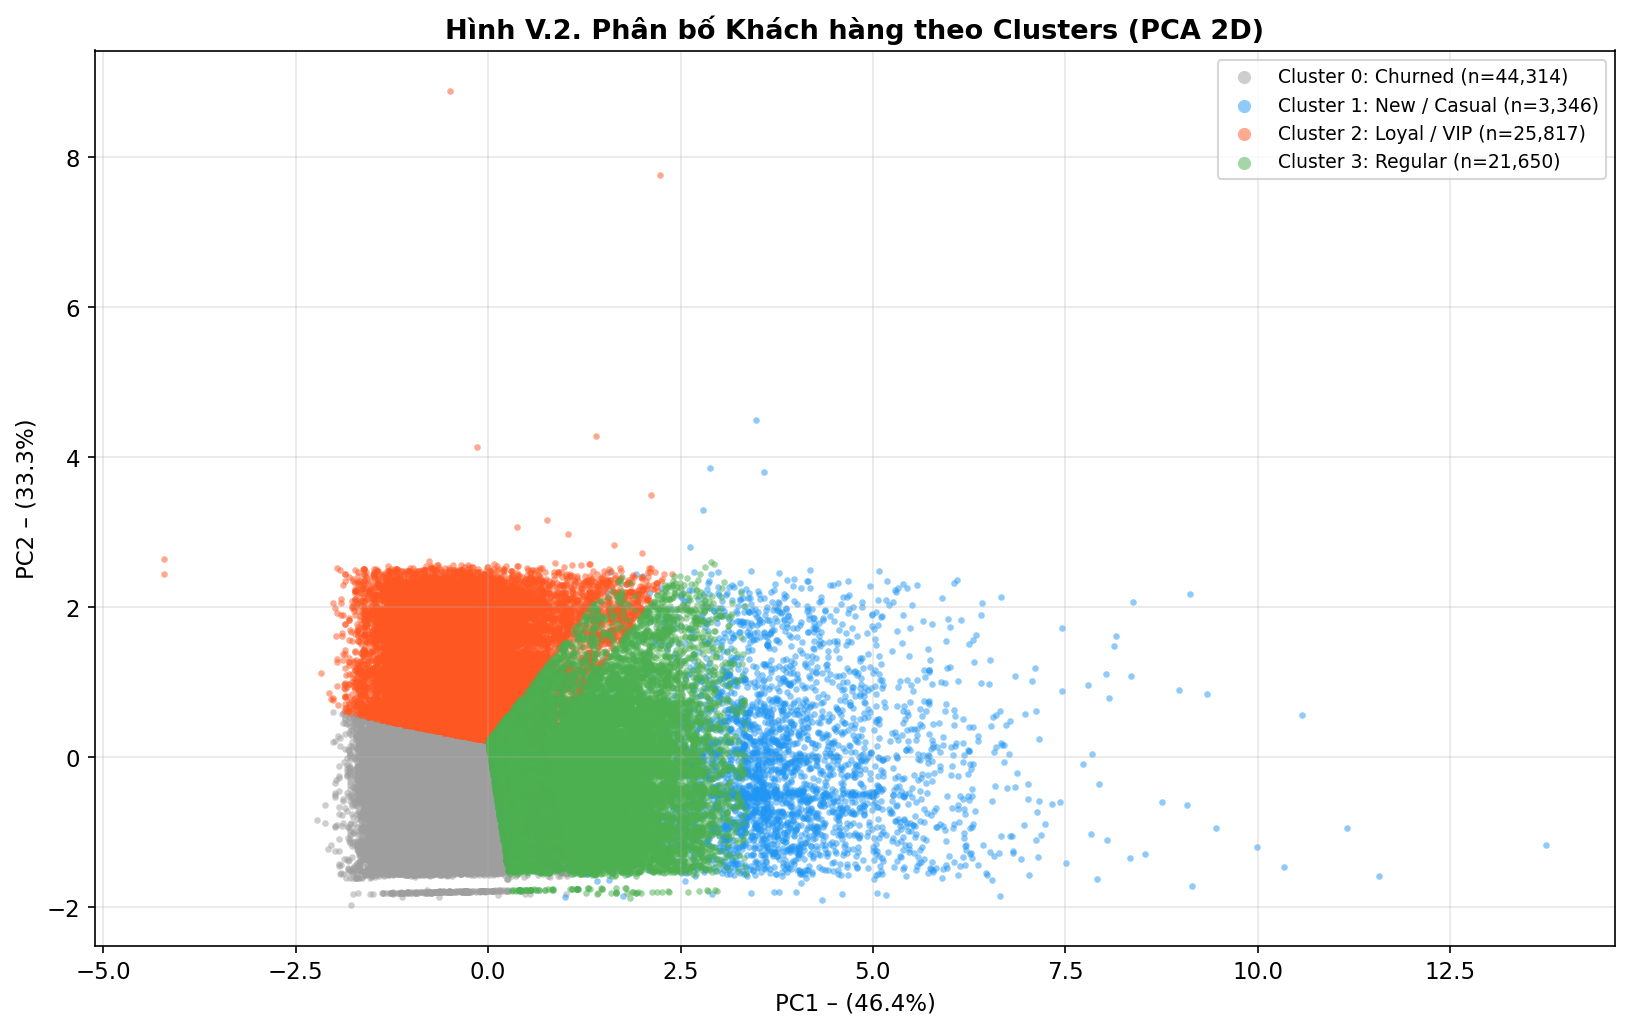

✅ Saved: /content/drive/MyDrive/Olist_Project/reports/figures/cluster_pca2d.png


In [30]:
# --- SCATTER PLOT PHÂN BỐ CLUSTERS (PCA 2D) ---
# Mục đích: Trực quan hoá phân bố khách hàng theo cluster trên không gian 2D

print("Đang vẽ Scatter Plot phân bố Clusters (PCA 2D)...")

from pyspark.ml.feature import PCA, VectorAssembler, StandardScaler
from pyspark.sql.functions import log1p, col, count, avg
from pyspark.ml.clustering import KMeans
import matplotlib.pyplot as plt
import os

FIGURE_PATH = "/content/drive/MyDrive/Olist_Project/reports/figures"
os.makedirs(FIGURE_PATH, exist_ok=True)

# --- Bước 1: Log transform để giảm skewness trước khi PCA ---
rfm_log = rfm_df_clean \
    .withColumn("recency_log",   log1p(col("recency"))) \
    .withColumn("frequency_log", log1p(col("frequency"))) \
    .withColumn("monetary_log",  log1p(col("monetary")))

assembler_log = VectorAssembler(
    inputCols=["recency_log", "frequency_log", "monetary_log"],
    outputCol="rfm_raw_log", handleInvalid="skip"
)
rfm_log_vec = assembler_log.transform(rfm_log)

scaler_log = StandardScaler(
    inputCol="rfm_raw_log", outputCol="rfm_scaled_log",
    withStd=True, withMean=True
).fit(rfm_log_vec)
rfm_scaled_log = scaler_log.transform(rfm_log_vec).cache()
print(f"  ✅ Log-scaled: {rfm_scaled_log.count():,} rows")

# --- Bước 2: Fit KMeans K=4 trên log-scaled features ---
kmeans_best  = KMeans(featuresCol="rfm_scaled_log", k=4, seed=42, maxIter=20)
model_best   = kmeans_best.fit(rfm_scaled_log)
rfm_clustered = model_best.transform(rfm_scaled_log)

# --- In Cluster Analysis để xác định nhãn ---
print("\n📌 Cluster Analysis (để gán nhãn đúng):")
# ✅ FIX: Chỉ lấy prediction và id từ bảng clustered để join, tránh trùng tên cột recency/frequency/monetary
rfm_clustered.select("customer_unique_id", "prediction") \
    .join(rfm_df_clean, on="customer_unique_id", how="left") \
    .groupBy("prediction").agg(
        count("*").alias("size"),
        avg("recency").alias("avg_recency"),
        avg("frequency").alias("avg_frequency"),
        avg("monetary").alias("avg_monetary")
    ).orderBy("prediction").show(truncate=False)

# --- Bước 3: PCA 2D ---
pca       = PCA(k=2, inputCol="rfm_scaled_log", outputCol="pca_features")
pca_model = pca.fit(rfm_clustered)
rfm_pca   = pca_model.transform(rfm_clustered)

# Variance explained
print(f"\n📌 PCA Explained Variance:")
print(f"  PC1: {pca_model.explainedVariance[0]*100:.1f}%")
print(f"  PC2: {pca_model.explainedVariance[1]*100:.1f}%")
print(f"  Total: {sum(pca_model.explainedVariance[:2])*100:.1f}%")

# --- Bước 4: Convert sang Pandas ---
pdf = rfm_pca.select("prediction", "pca_features").toPandas()
pdf["pc1"] = pdf["pca_features"].apply(lambda x: float(x[0]))
pdf["pc2"] = pdf["pca_features"].apply(lambda x: float(x[1]))

print(f"\n  Tổng khách hàng: {len(pdf):,}")
for i in range(4):
    print(f"  Cluster {i}: {(pdf['prediction']==i).sum():,}")

# --- Bước 5: Gán nhãn dựa theo Cluster Analysis ---
cluster_labels = {
    0: "Cluster 0: Churned",
    1: "Cluster 1: New / Casual",
    2: "Cluster 2: Loyal / VIP",
    3: "Cluster 3: Regular"
}
colors = ['#9E9E9E', '#2196F3', '#FF5722', '#4CAF50']

# --- Bước 6: Vẽ biểu đồ ---
fig, ax = plt.subplots(figsize=(11, 7))

for i in range(4):
    mask = pdf["prediction"] == i
    n    = mask.sum()
    ax.scatter(
        pdf[mask]["pc1"], pdf[mask]["pc2"],
        c=colors[i],
        label=f"{cluster_labels[i]} (n={n:,})",
        alpha=0.5, s=10, linewidths=0
    )

ax.set_xlabel(f'PC1 – ({pca_model.explainedVariance[0]*100:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 – ({pca_model.explainedVariance[1]*100:.1f}%)', fontsize=11)
ax.set_title('Hình V.2. Phân bố Khách hàng theo Clusters (PCA 2D)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, markerscale=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()

SAVE_PNG = f"{FIGURE_PATH}/cluster_pca2d.png"
plt.savefig(SAVE_PNG, dpi=200, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {SAVE_PNG}")


📊 THỐNG KÊ & PHÂN TÍCH BỔ SUNG

📌 Ma trận tương quan các features số:


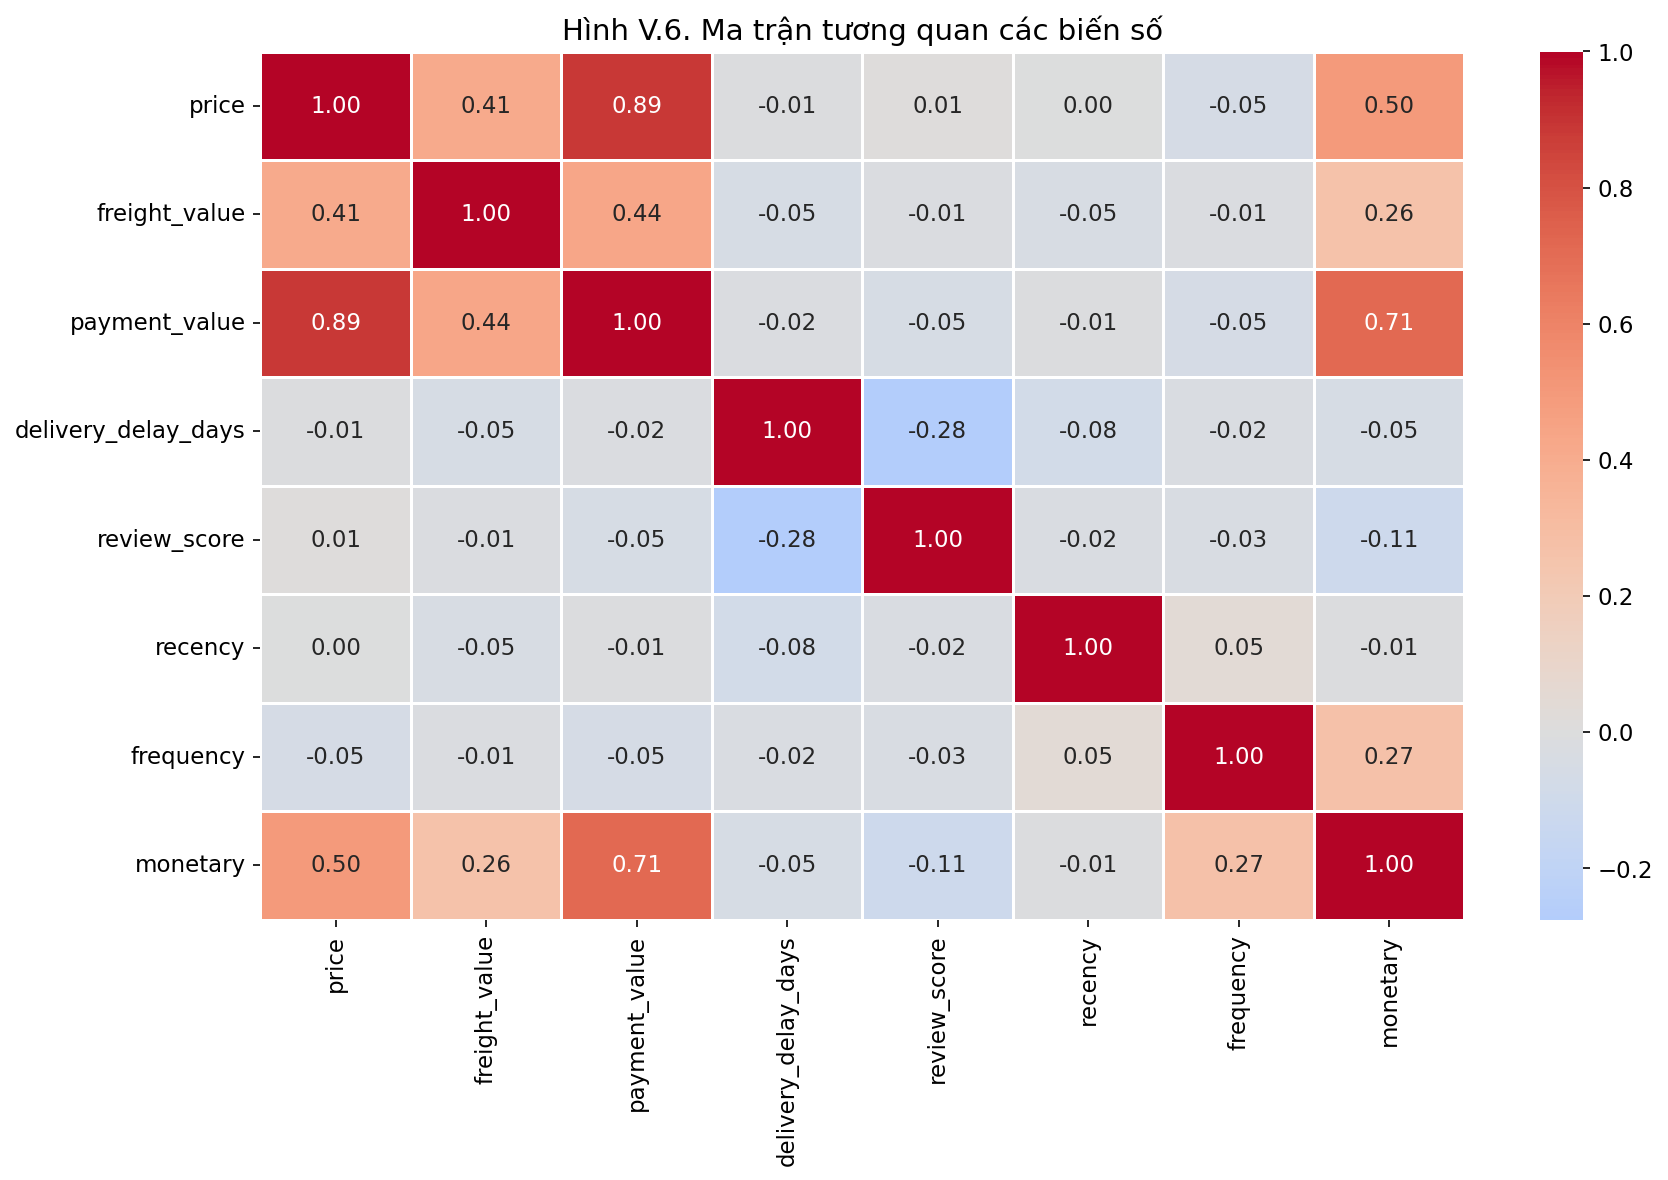

In [31]:
# =============================================================================
# [9B] THỐNG KÊ & PHÂN TÍCH BỔ SUNG
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
print("\n" + "="*60)
print("📊 THỐNG KÊ & PHÂN TÍCH BỔ SUNG")
print("="*60)

# [9.1] Ma trận tương quan
print("\n📌 Ma trận tương quan các features số:")
# Sử dụng rfm_df_clean thay vì df_master để có các cột RFM
# Cũng cần đảm bảo df_master có các cột cần thiết hoặc chỉ dùng các cột RFM
numeric_cols_rfm = ["recency", "frequency", "monetary"]
numeric_cols_master = ["price", "freight_value", "payment_value", "delivery_delay_days", "review_score"]

# Lấy các cột từ df_master, bao gồm customer_unique_id để join
df_master_selected = df_master.select(numeric_cols_master + ["customer_unique_id"])

# Lấy các cột từ rfm_df_clean
df_rfm_selected = rfm_df_clean.select(numeric_cols_rfm + ["customer_unique_id"])

# Join hai DataFrame để tạo một DataFrame cho ma trận tương quan
# Loại bỏ các cột trùng lặp nếu có, ở đây customer_unique_id chỉ để join
df_combined_for_corr = df_master_selected.join(
    df_rfm_selected,
    on=df_master_selected["customer_unique_id"] == df_rfm_selected["customer_unique_id"],
    how="inner"
).drop(df_rfm_selected["customer_unique_id"])

# Lọc ra các cột số đã chọn
final_corr_cols = numeric_cols_master + numeric_cols_rfm

# Đảm bảo tất cả các cột là số (nếu có thể)
for col_name in final_corr_cols:
    if col_name in df_combined_for_corr.columns:
        df_combined_for_corr = df_combined_for_corr.withColumn(col_name, col(col_name).cast("double"))

# Tính ma trận tương quan trên DataFrame đã join
# Sử dụng .toPandas() trước khi tính corr nếu muốn dùng pandas corr
pdf_corr = df_combined_for_corr.toPandas()

plt.figure(figsize=(12, 8))
sns.heatmap(pdf_corr.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=.5)
plt.title('Hình V.6. Ma trận tương quan các biến số')
plt.tight_layout()
plt.savefig(f"{FIGURE_PATH}/correlation_matrix.png", dpi=200)
plt.show()

In [32]:
# [9.2] Chi-square Test
print("\n📌 Kiểm định Chi-square cho các biến phân loại:")
from scipy.stats import chi2_contingency

# Kiểm tra mối quan hệ giữa order_status và payment_type
contingency_table = df_master.groupBy("order_status", "payment_type").count()
print("\nContingency Table: order_status vs payment_type")
contingency_table.show()

# Convert to pandas cho chi2 test
pdf_contingency = contingency_table.toPandas()
pivot_table = pdf_contingency.pivot(index="order_status",
                                     columns="payment_type",
                                     values="count").fillna(0)
print("\nPivot Table:")
print(pivot_table)

# Perform Chi-square test
chi2, p, dof, expected = chi2_contingency(pivot_table)
print(f"\nChi-square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")

if p < 0.05:
    print("✅ Kết luận: Có mối quan hệ có ý nghĩa thống kê (p < 0.05)")
else:
    print("❌ Kết luận: Không có mối quan hệ có ý nghĩa thống kê (p >= 0.05)")


📌 Kiểm định Chi-square cho các biến phân loại:

Contingency Table: order_status vs payment_type
+------------+------------+-----+
|order_status|payment_type|count|
+------------+------------+-----+
|     shipped|      boleto|  226|
| unavailable|     voucher|   47|
|    canceled|  debit_card|    7|
|     shipped| credit_card|  922|
|    canceled|      boleto|  112|
|     shipped|  debit_card|   23|
|     shipped|     voucher|   85|
|    invoiced|     voucher|   14|
|  processing|      boleto|   97|
|    canceled| credit_card|  513|
|    canceled|     voucher|  115|
|   delivered|      boleto|22505|
|  processing|  debit_card|    2|
| unavailable| credit_card|  447|
| unavailable|  debit_card|    6|
|  processing|     voucher|   23|
|  processing| credit_card|  254|
|     created| credit_card|    3|
|    invoiced|      boleto|   96|
| unavailable|      boleto|  152|
+------------+------------+-----+
only showing top 20 rows

Pivot Table:
payment_type   boleto  credit_card  debit_card  

In [38]:
# =============================================================================
# [10] RECOMMENDATION (ALS) & FP-GROWTH
# =============================================================================
import time
print("\n" + "="*60)
print("🎁 RECOMMENDATION & FP-GROWTH")
print("="*60)

from pyspark.ml.recommendation import ALS
from pyspark.ml.feature import StringIndexer
from pyspark.ml.fpm import FPGrowth
from pyspark.sql.functions import collect_list, collect_set, size, col

# ── ALS ─────────────────────────────────────────────────────────────
print("\n📌 ALS Recommendation...")
try:
    df_als_raw = df_master.select(
        "customer_unique_id", "product_id", "review_score"
    ).dropna()

    # StringIndexer để chuyển string → integer cho user và item
    user_indexer = StringIndexer(inputCol="customer_unique_id",
                                 outputCol="user_idx").fit(df_als_raw)
    item_indexer = StringIndexer(inputCol="product_id",
                                 outputCol="item_idx").fit(df_als_raw)
    df_als = item_indexer.transform(user_indexer.transform(df_als_raw)) \
        .select(
            col("user_idx").cast("int").alias("user"),
            col("item_idx").cast("int").alias("item"),
            col("review_score").cast("float").alias("rating")
        ).dropna()

    train_als, test_als = df_als.randomSplit([0.8, 0.2], seed=42)

    als = ALS(
        rank=10, maxIter=10, regParam=0.01,
        userCol="user", itemCol="item", ratingCol="rating",
        coldStartStrategy="drop", implicitPrefs=False
    )
    t0        = time.time()
    als_model = als.fit(train_als)
    als_preds = als_model.transform(test_als)

    from pyspark.ml.evaluation import RegressionEvaluator
    rmse_als = RegressionEvaluator(labelCol="rating", metricName="rmse").evaluate(als_preds)
    print(f"  ✅ ALS RMSE: {rmse_als:.4f} | Time: {time.time()-t0:.1f}s")

    user_recs = als_model.recommendForAllUsers(10)
    print("  ✅ Sample recommendations (5 users):")
    user_recs.limit(5).show(truncate=False)

    als_model.write().overwrite().save(SAVE_PATH + "/als_model")
    print("  ✅ ALS model đã lưu")

except Exception as e:
    print(f"  ❌ ALS Error: {str(e)}")

# ── FP-Growth ────────────────────────────────────────────────────────
print("\n📌 FP-Growth Association Rules...")
try:
    df_basket = df_master \
        .filter(col("product_category_name_english").isNotNull()) \
        .filter(col("order_id").isNotNull()) \
        .groupBy("order_id") \
        .agg(collect_set("product_category_name_english").alias("items"))

    # ✅ FIX: chỉ giữ transaction có >= 2 items để sinh được rules
    df_basket_all   = df_basket.filter(size(col("items")) >= 1)
    df_basket_multi = df_basket.filter(size(col("items")) >= 2)

    total_all   = df_basket_all.count()
    total_multi = df_basket_multi.count()
    print(f"  Tổng transactions       : {total_all}")
    print(f"  Transaction ≥ 2 items   : {total_multi} ({100*total_multi/total_all:.1f}%)")

    # ✅ FIX: fit trên basket multi-item, hạ minSupport, minConfidence=0.0
    fp = FPGrowth(
        itemsCol="items",
        minSupport=0.001,
        minConfidence=0.0
    )
    t0       = time.time()
    fp_model = fp.fit(df_basket_multi)
    elapsed  = time.time() - t0

    freq_count  = fp_model.freqItemsets.count()
    rules_count = fp_model.associationRules.count()
    print(f"  ✅ FP-Growth: {freq_count} itemsets | {rules_count} rules | {elapsed:.1f}s")

    print("\n  📋 Frequent Itemsets (top 10 phổ biến nhất):")
    fp_model.freqItemsets \
        .orderBy("freq", ascending=False) \
        .show(10, truncate=False)

    if rules_count > 0:
        print("\n  🔗 Top 10 Association Rules (theo lift):")
        fp_model.associationRules \
            .filter(col("confidence") >= 0.1) \
            .orderBy("lift", ascending=False) \
            .select("antecedent", "consequent", "support", "confidence", "lift") \
            .show(10, truncate=False)
    else:
        print("\n  ⚠️ Không sinh được rules (Olist chủ yếu 1 sản phẩm/order).")
        print("  → Frequent itemsets vẫn thể hiện danh mục hay mua chung.")

    fp_model.write().overwrite().save(SAVE_PATH + "/fp_model")
    print("  ✅ FP-Growth model đã lưu")

except Exception as e:
    print(f"  ❌ FP-Growth Error: {str(e)}")


🎁 RECOMMENDATION & FP-GROWTH

📌 ALS Recommendation...
  ✅ ALS RMSE: 1.9691 | Time: 76.1s
  ✅ Sample recommendations (5 users):
+----+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|user|recommendations                                                                                                                                                                             |
+----+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|3   |[{2750, 7.738021}, {1926, 6.9918833}, {1829, 6.943836}, {1323, 6.7216144}, {5162, 6.6406574}, {4857, 6.5196524}, {3827, 6.328141}, {705, 6.2742405}, {1783, 6.115215}, {3043, 6.10497}]     |
|4   |[{536, 7.0671816}, {2920, 6.920488}, {3682, 6.673922}, {2577, 6.5074043}, {3863, 6

In [39]:
# Tổng hợp tất cả metrics
print("\n" + "="*60)
print("📋 TỔNG HỢP METRICS TẤT CẢ MODELS")
print("="*60)

# Classification metrics
df_cls_metrics = pd.DataFrame([
    {"Model": k,
     "Accuracy": v.get("acc", float('nan')),
     "Precision": v.get("prec", float('nan')),
     "Recall": v.get("rec", float('nan')),
     "F1": v.get("f1", float('nan')),
     "AUC": v.get("auc", float('nan')),
     "Time(s)": v.get("time", float('nan'))}
    for k, v in cls_results.items()
])
print("\nClassification Models:")
print(df_cls_metrics.to_string(index=False))

# Regression metrics
df_reg_metrics = pd.DataFrame([
    {"Model": k, "RMSE": v["rmse"], "MAE": v["mae"],
     "R2": v["r2"], "Time(s)": v["time"]}
    for k, v in reg_results.items()
])
print("\nRegression Models:")
print(df_reg_metrics.to_string(index=False))

# Clustering metrics
print("\nClustering Models:")
print(f" K-Means: Silhouette={cluster_results['KMeans']['sil']:.4f}")
print(f" BisectingKMeans: Silhouette={cluster_results['BisectingKMeans']['sil']:.4f}")
print(f" GaussianMixture: Silhouette={cluster_results['GaussianMixture']['sil']:.4f}")

# Lưu metrics vào CSV
df_cls_metrics.to_csv(f"{FIGURE_PATH}/classification_metrics.csv", index=False)
df_reg_metrics.to_csv(f"{FIGURE_PATH}/regression_metrics.csv", index=False)
print(f"\n✅ Đã lưu metrics vào {FIGURE_PATH}")


📋 TỔNG HỢP METRICS TẤT CẢ MODELS

Classification Models:
                   Model  Accuracy  Precision   Recall       F1      AUC     Time(s)
      LogisticRegression  0.786421   0.799632 0.786421 0.730983 0.673457    8.723897
            RandomForest  0.800889   0.805250 0.800889 0.760732 0.698740   23.668433
              NaiveBayes  0.768179   0.790160 0.768179 0.691348 0.589287    2.398793
               LinearSVC  0.768179   0.790160 0.768179 0.691348 0.694746   39.961416
           GBTClassifier  0.806550   0.808393 0.806550 0.771522 0.726363   59.296951
     GBTClassifier_tuned  0.809570        NaN      NaN 0.777954 0.732736 1003.438241
LogisticRegression_tuned  0.786421        NaN      NaN 0.730983 0.673457   77.257013

Regression Models:
                      Model       RMSE       MAE       R2    Time(s)
           LinearRegression 198.320690 66.803797 0.512888  12.333665
      DecisionTreeRegressor 190.188435 70.547382 0.552018   8.461964
      RandomForestRegressor 166.031

In [40]:
# =============================================================================
# TỔNG KẾT KẾT QUẢ TUẦN 2
# =============================================================================
print("\n" + "="*60)
print("📊 TỔNG KẾT KẾT QUẢ TUẦN 2")
print("="*60)

# ── CLASSIFICATION ────────────────────────────────────────────────────────────
print("\n✅ CLASSIFICATION:")
print(f"  {'Model':<22} {'Acc':>8} {'Prec':>8} {'Recall':>8} {'F1':>8} {'AUC':>8} {'Time':>7}")
print("  " + "-"*70)
for name, v in cls_results.items():
    auc_str = f"{v['auc']:>8.4f}" if not (v['auc'] != v['auc']) else f"{'N/A':>8}"
    # Sử dụng .get() để tránh KeyError cho các mô hình đã tinh chỉnh không có đủ metrics
    prec_str = f"{v.get('prec', float('nan')):>8.4f}" if not (v.get('prec', float('nan')) != v.get('prec', float('nan'))) else f"{'N/A':>8}"
    rec_str = f"{v.get('rec', float('nan')):>8.4f}" if not (v.get('rec', float('nan')) != v.get('rec', float('nan'))) else f"{'N/A':>8}"
    f1_str = f"{v.get('f1', float('nan')):>8.4f}" if not (v.get('f1', float('nan')) != v.get('f1', float('nan'))) else f"{'N/A':>8}"
    time_str = f"{v.get('time', float('nan')):>6.1f}s" if not (v.get('time', float('nan')) != v.get('time', float('nan'))) else f"{'N/A':>6}"

    print(f"  {name:<22} {v['acc']:>8.4f} {prec_str} {rec_str} {f1_str} {auc_str} {time_str}")
best_cls = max(cls_results, key=lambda k: cls_results[k]["acc"])
print(f"  🏆 Best: {best_cls} (Acc={cls_results[best_cls]['acc']:.4f} | F1={cls_results[best_cls].get('f1', float('nan')):.4f})")

# ── REGRESSION ────────────────────────────────────────────────────────────────
print("\n✅ REGRESSION:")
for name, v in reg_results.items():
    print(f"  {name:<26} RMSE={v['rmse']:.4f} R²={v['r2']:.4f}")
best_reg = min(reg_results, key=lambda k: reg_results[k]["rmse"])
print(f"  🏆 Best: {best_reg}")

# ── CLUSTERING ────────────────────────────────────────────────────────────────
print("\n✅ CLUSTERING:")
if 'cluster_results' in locals():
    for name, v in cluster_results.items():
        print(f"  {name:<22} Silhouette={v['sil']:.4f} | Time={v['time']:.1f}s")
    print(f"  🏆 Optimal K: 4 (KMeans Silhouette={cluster_results.get('KMeans', {}).get('sil', 0):.4f})")

# ── ALS ───────────────────────────────────────────────────────────────────────
print("\n✅ ALS RECOMMENDATION:")
if 'rmse_als' in locals():
    print(f"  RMSE       : {rmse_als:.4f}")
    print(f"  Rank       : 10 | MaxIter: 10 | RegParam: 0.01")
    print(f"  Model path : {SAVE_PATH}/als_model")

# ── FP-GROWTH ─────────────────────────────────────────────────────────────────
print("\n✅ FP-GROWTH:")
if 'fp_model' in locals():
    print(f"  Frequent itemsets : {fp_model.freqItemsets.count()}")
    print(f"  Association rules : {fp_model.associationRules.count()}")
    print(f"  Model path        : {SAVE_PATH}/fp_model")

print("\n" + "="*60)
print(f"✅ Tất cả models đã được lưu tại: {SAVE_PATH}")
print("="*60)



📊 TỔNG KẾT KẾT QUẢ TUẦN 2

✅ CLASSIFICATION:
  Model                       Acc     Prec   Recall       F1      AUC    Time
  ----------------------------------------------------------------------
  LogisticRegression       0.7864   0.7996   0.7864   0.7310   0.6735    8.7s
  RandomForest             0.8009   0.8052   0.8009   0.7607   0.6987   23.7s
  NaiveBayes               0.7682   0.7902   0.7682   0.6913   0.5893    2.4s
  LinearSVC                0.7682   0.7902   0.7682   0.6913   0.6947   40.0s
  GBTClassifier            0.8066   0.8084   0.8066   0.7715   0.7264   59.3s
  GBTClassifier_tuned      0.8096      N/A      N/A   0.7780   0.7327 1003.4s
  LogisticRegression_tuned   0.7864      N/A      N/A   0.7310   0.6735   77.3s
  🏆 Best: GBTClassifier_tuned (Acc=0.8096 | F1=0.7780)

✅ REGRESSION:
  LinearRegression           RMSE=198.3207 R²=0.5129
  DecisionTreeRegressor      RMSE=190.1884 R²=0.5520
  RandomForestRegressor      RMSE=166.0317 R²=0.6586
  RandomForestRegressor_tu

In [43]:
# =============================================================================
# STREAMLIT APP - OLIST E-COMMERCE ANALYTICS
# Chạy trên Google Colab với ngrok
# =============================================================================

# =============================================================================
# [12] CÀI ĐẶT STREAMLIT CHO TUẦN 3
# =============================================================================
!pip install streamlit pyngrok -q
print("✅ Đã cài đặt Streamlit và pyngrok")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 103.3 MB/s eta 0:00:00
✅ Đã cài đặt Streamlit và pyngrok


In [41]:
# =============================================================================
# [EXPORT] Xuất dữ liệu cho Streamlit (FIXED ALS COLUMN ERROR)
# =============================================================================
import os, pickle
import pandas as pd
from pyspark.sql.functions import col, explode
# Import necessary Spark ML models for loading
from pyspark.ml.recommendation import ALSModel
from pyspark.ml.fpm import FPGrowthModel
from sklearn.ensemble import GradientBoostingClassifier, RandomForestRegressor # Required for pickle loading

EXPORT_PATH = "/content/drive/MyDrive/OlistProject/streamlit_data"
SAVE_PATH = "/content/drive/MyDrive/OlistProject/models/week2" # Ensure SAVE_PATH is defined
os.makedirs(EXPORT_PATH, exist_ok=True)

# ── 1. RFM + Clusters ────────────────────────────────────────────────────────
if 'rfm_clustered' in locals() and rfm_clustered.count() > 0:
    rfm_export = rfm_clustered.select(
        "customer_unique_id",
        "recency",
        "frequency",
        "monetary",
        "prediction"
    ).toPandas()

    rfm_export.to_csv(f"{EXPORT_PATH}/rfm_clusters.csv", index=False, encoding='utf-8')
    print("✅ rfm_clusters.csv")
else:
    print("⚠️ rfm_clustered DataFrame không tồn tại hoặc rỗng, bỏ qua xuất RFM clusters.")

# ── 2. Dashboard stats ────────────────────────────────────────────────────────
stats = {
    "total_orders":    df_master.select("order_id").distinct().count(),
    "total_customers": df_master.select("customer_unique_id").distinct().count(),
    "total_products":  df_master.select("product_id").distinct().count(),
    "avg_payment":     df_master.agg({"payment_value":"avg"}).collect()[0][0],
    "avg_review":      df_master.agg({"review_score":"avg"}).collect()[0][0],
}
pd.DataFrame([stats]).to_csv(f"{EXPORT_PATH}/stats.csv", index=False)
print("✅ stats.csv")

# ── 3. Review score distribution ────────────────────────────────────────────────────────
review_dist = df_master.groupBy("review_score").count().orderBy("review_score").toPandas()
review_dist.to_csv(f"{EXPORT_PATH}/review_dist.csv", index=False)
print("✅ review_dist.csv")

# ── 4. Payment type distribution ────────────────────────────────────────────────────────
payment_dist = df_master.groupBy("payment_type").count().toPandas()
payment_dist.to_csv(f"{EXPORT_PATH}/payment_dist.csv", index=False)
print("✅ payment_dist.csv")

# ── 5. Top categories ────────────────────────────────────────────────────────
top_cat = df_master.groupBy("product_category_name_english").count() \
    .orderBy("count", ascending=False).limit(10).toPandas()
top_cat.to_csv(f"{EXPORT_PATH}/top_categories.csv", index=False)
print("✅ top_categories.csv")

# ── 6. ALS recommendations ────────────────────────────────────────────────────────
als_model = None # Reset als_model to ensure loading from disk
als_parquet_full_path = f"{EXPORT_PATH}/als_recommendations_full.parquet" # Full Spark DF path
als_csv_sample_path = f"{EXPORT_PATH}/als_recommendations.csv" # Sampled CSV for Streamlit

try:
    als_model = ALSModel.load(SAVE_PATH + "/als_model")
    print("💡 ALS model đã được load lại.")
    als_recs = als_model.recommendForAllUsers(10)
    print("💡 Đã tạo ALS recommendations (Spark DataFrame).")
    als_flat = als_recs.select(
        col("user").alias("user_idx"),
        explode("recommendations").alias("rec")
    ).select("user_idx", col("rec.item").alias("item_idx"), col("rec.rating"))
    print("💡 Đã làm phẳng ALS recommendations (Spark DataFrame).")

    # Step 1: Save the full als_flat Spark DataFrame to Parquet
    als_flat.write.mode("overwrite").parquet(als_parquet_full_path)
    print(f"💡 Đã lưu toàn bộ ALS recommendations vào Parquet: {als_parquet_full_path}")

    # Step 2: Read a fixed number of rows from the Parquet file into a Pandas DataFrame
    # This ensures a manageable size for Streamlit, e.g., 50,000 rows
    num_sample_rows_for_streamlit = 50000 # You can adjust this number
    sampled_als_df_for_pandas = spark.read.parquet(als_parquet_full_path).limit(num_sample_rows_for_streamlit)
    pd_als_sample = sampled_als_df_for_pandas.toPandas() # Convert only this limited set to Pandas
    print("💡 Đã đọc mẫu ALS recommendations từ Parquet và chuyển đổi sang Pandas.")

    # Step 3: Save the sampled Pandas DataFrame to CSV
    pd_als_sample.to_csv(als_csv_sample_path, index=False)
    print(f"✅ als_recommendations.csv (limited to {num_sample_rows_for_streamlit} rows from Parquet) đã lưu.")

except Exception as e:
    print(f"❌ Lỗi khi tải hoặc xuất ALS recommendations: {e}")

# ── 7. Association rules ────────────────────────────────────────────────────────
fp_model = None # Reset fp_model to ensure loading from disk
fp_csv_path = f"{EXPORT_PATH}/association_rules.csv"

try:
    fp_model = FPGrowthModel.load(SAVE_PATH + "/fp_model")
    print("💡 FP-Growth model đã được load lại.")

    # FP-Growth rules are usually smaller, direct toPandas() might be fine
    # If this also causes memory error, consider sampling or saving to parquet first
    fp_model.associationRules.toPandas().to_csv(fp_csv_path, index=False)
    print(f"✅ association_rules.csv đã lưu.")
except Exception as e:
    print(f"❌ Lỗi khi tải hoặc xuất Association rules: {e}")

# ── 8. Classification metrics ────────────────────────────────────────────────────────
metrics_data = [{
    "Model": k,
    "Accuracy": v.get("acc", float('nan')),
    "Precision": v.get("prec", float('nan')),
    "Recall": v.get("rec", float('nan')),
    "F1": v.get("f1", float('nan')),
    "AUC": v.get("auc", float('nan')),
    "Time(s)": v.get("time", float('nan'))}
    for k, v in cls_results.items()]
pd.DataFrame(metrics_data).to_csv(f"{EXPORT_PATH}/cls_metrics.csv", index=False)
print("✅ cls_metrics.csv")

# ── 9. Regression metrics ────────────────────────────────────────────────────────
reg_data = [{
    "Model": k,
    "RMSE": v.get("rmse", float('nan')),
    "MAE": v.get("mae", float('nan')),
    "R2": v.get("r2", float('nan')),
    "Time(s)": v.get("time", float('nan'))}
            for k, v in reg_results.items()]
pd.DataFrame(reg_data).to_csv(f"{EXPORT_PATH}/reg_metrics.csv", index=False)
print("✅ reg_metrics.csv")

# ── 10. Sklearn models (Dành cho chức năng dự đoán real-time trên App)
# These models are assumed to be saved by the previous cells and need to be explicitly loaded here
gbt_model_path = f"{EXPORT_PATH}/gbt_model.pkl"
rfr_model_path = f"{EXPORT_PATH}/rf_regressor.pkl"

gbt_sk = None
rfr_sk = None

# Load or (re)train GBT Classifier
if os.path.exists(gbt_model_path):
    try:
        with open(gbt_model_path, "rb") as f:
            gbt_sk = pickle.load(f)
        print("💡 GBT Classifier đã được load lại.")
    except Exception as e:
        print(f"❌ Không thể load GBT Classifier: {e}")
else:
    print("⚠️ gbt_model.pkl không tồn tại. Đang huấn luyện lại sklearn models...")
    # Make sure df_transformed is available if retraining
    if 'df_transformed' not in locals():
        print("❌ df_transformed không tồn tại. Không thể huấn luyện lại sklearn models.")
    else:
        df_sk = df_transformed.select(
            "price", "freight_value", "delivery_delay_days",
            "payment_type_idx", "review_score", "payment_value"
        ).dropna().toPandas()

        X = df_sk[["price","freight_value","delivery_delay_days","payment_type_idx"]].values
        y_clf = (df_sk["review_score"] >= 4).astype(int).values

        gbt_sk = GradientBoostingClassifier(n_estimators=50, max_depth=5, random_state=42)
        gbt_sk.fit(X, y_clf)
        with open(gbt_model_path, "wb") as f:
            pickle.dump(gbt_sk, f)
        print("✅ gbt_model.pkl (re-trained and saved)")

# Load or (re)train Random Forest Regressor
if os.path.exists(rfr_model_path):
    try:
        with open(rfr_model_path, "rb") as f:
            rfr_sk = pickle.load(f)
        print("💡 Random Forest Regressor đã được load lại.")
    except Exception as e:
        print(f"❌ Không thể load Random Forest Regressor: {e}")
else:
    print("⚠️ rf_regressor.pkl không tồn tại. Đang huấn luyện lại sklearn models...")
    if 'df_transformed' not in locals(): # Check again for df_transformed if GBT block skipped
        print("❌ df_transformed không tồn tại. Không thể huấn luyện lại sklearn models.")
    else:
        # df_sk and X, y_reg should be available from the GBT block if it ran
        if 'df_sk' not in locals():
            df_sk = df_transformed.select(
                "price", "freight_value", "delivery_delay_days",
                "payment_type_idx", "review_score", "payment_value"
            ).dropna().toPandas()

            X = df_sk[["price","freight_value","delivery_delay_days","payment_type_idx"]].values
            y_reg = df_sk["payment_value"].values

        rfr_sk = RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42)
        rfr_sk.fit(X, y_reg)
        with open(rfr_model_path, "wb") as f:
            pickle.dump(rfr_sk, f)
        print("✅ rf_regressor.pkl (re-trained and saved)")


print(f"\n✨ HOÀN TẤT! Dữ liệu đã sẵn sàng tại: {EXPORT_PATH}")

✅ rfm_clusters.csv
✅ stats.csv
✅ review_dist.csv
✅ payment_dist.csv
✅ top_categories.csv
💡 ALS model đã được load lại.
💡 Đã tạo ALS recommendations (Spark DataFrame).
💡 Đã làm phẳng ALS recommendations (Spark DataFrame).
💡 Đã lưu toàn bộ ALS recommendations vào Parquet: /content/drive/MyDrive/OlistProject/streamlit_data/als_recommendations_full.parquet
💡 Đã đọc mẫu ALS recommendations từ Parquet và chuyển đổi sang Pandas.
✅ als_recommendations.csv (limited to 50000 rows from Parquet) đã lưu.
💡 FP-Growth model đã được load lại.
✅ association_rules.csv đã lưu.
✅ cls_metrics.csv
✅ reg_metrics.csv
💡 GBT Classifier đã được load lại.
💡 Random Forest Regressor đã được load lại.

✨ HOÀN TẤT! Dữ liệu đã sẵn sàng tại: /content/drive/MyDrive/OlistProject/streamlit_data
